In [22]:
import numpy as np
import random
import argparse
import json
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [23]:
def get_dataset_name(dataset_id, nnunet_raw):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [
        d for d in os.listdir(nnunet_raw)
        if d.startswith(f"Dataset{dataset_id}") and os.path.isdir(os.path.join(nnunet_raw, d))
    ]
    if len(dataset_name) != 1:
        raise RuntimeError(f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1")
    return dataset_name[0]

def extract_params(model_dir):
    metrics_file = f"{model_dir}/model_analysis.json"
    with open(metrics_file, 'r') as f:
        metrics = json.load(f)
    return metrics['parameters']['total']

def get_dice(results_dir, dataset_name, trainer, plans, cfg, fold=0, split="test", allow_validation_fallback=True):
    model_dir = f"{results_dir}/{dataset_name}/{trainer}__{plans}__{cfg}"

    params = np.nan
    metrics_file = f"{model_dir}/model_analysis.json"
    if os.path.exists(metrics_file):
        with open(metrics_file, "r") as f:
            metrics = json.load(f)
        params = metrics.get("parameters", {}).get("total", np.nan)

    dice = np.nan
    dice_std = np.nan
    dice_cases = []

    test_dir = f"{model_dir}/fold_{fold}/test"
    results_csv = f"{test_dir}/results.csv"

    # Primary source: fold_X/test/results.csv for this trainer/config.
    if os.path.exists(results_csv):
        df = pd.read_csv(results_csv)
        if not df.empty:
            if "test_dataset_name" in df.columns:
                df_sel = df[df["test_dataset_name"] == dataset_name]
                if df_sel.empty:
                    df_sel = df
            else:
                df_sel = df

            row = df_sel.iloc[-1]
            if "dice" in row.index and pd.notna(row["dice"]):
                dice = float(row["dice"])
            if "dice_std" in row.index and pd.notna(row["dice_std"]):
                dice_std = float(row["dice_std"])

            image_wise_csv = f"{test_dir}/image_wise_{Path(results_csv).stem}_{dataset_name}.csv"
            if os.path.exists(image_wise_csv):
                df_img = pd.read_csv(image_wise_csv)
                if "dice" in df_img.columns:
                    vals = pd.to_numeric(df_img["dice"], errors="coerce").dropna().astype(float).to_numpy()
                    if vals.size > 0:
                        dice_cases = vals.tolist()
                        if not np.isfinite(dice_std):
                            dice_std = float(np.std(vals))


    elif allow_validation_fallback and "brats" in dataset_name.lower():
        # BraTS often has validation summaries only.
        metrics_file = f"{model_dir}/fold_{fold}/validation/summary.json"
        if os.path.exists(metrics_file):
            with open(metrics_file, "r") as f:
                metrics = json.load(f)
            if "foreground_mean" in metrics and "Dice" in metrics["foreground_mean"]:
                dice = float(metrics["foreground_mean"]["Dice"]) * 100.0

            dice_per_case = []
            for case in metrics.get("metric_per_case", []):
                case_metrics = case.get("metrics", {})
                class_key = next(iter(case_metrics), None)
                if class_key is None:
                    continue
                dice_val = case_metrics[class_key].get("Dice")
                if dice_val is not None:
                    dice_per_case.append(float(dice_val) * 100.0)
            if len(dice_per_case) > 0:
                dice_cases = dice_per_case
                dice_std = float(np.std(np.asarray(dice_per_case, dtype=float)))

    return {
        "dice": dice,
        "dice_std": dice_std,
        "dice_cases": dice_cases,
        "params": params,
    }

def get_baseline_results_csv(model_dir, dataset_name):
    csv_path = f"{model_dir}/fold_0/test/results.csv"
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        if not df.empty:
            if "test_dataset_name" in df.columns:
                df_sel = df[df["test_dataset_name"] == dataset_name]
                if df_sel.empty:
                    df_sel = df
            else:
                df_sel = df
            row = df_sel.iloc[-1]
            if "dice" in row.index and pd.notna(row["dice"]):
                return float(row["dice"])

    # Fallback to image-wise dice if aggregate results.csv is absent/invalid.
    image_wise_csv = f"{model_dir}/fold_0/test/image_wise_results_{dataset_name}.csv"
    if os.path.exists(image_wise_csv):
        df_img = pd.read_csv(image_wise_csv)
        if "dice" in df_img.columns:
            vals = pd.to_numeric(df_img["dice"], errors="coerce").dropna().astype(float).to_numpy()
            if vals.size > 0:
                return float(np.mean(vals))

    raise FileNotFoundError(f"No baseline results found at {csv_path} or {image_wise_csv}")


def get_baseline_results(dataset_id, baselines=("TinyUNet", "CMUNeXt-S", "UNeXt"), nnunet_raw="data/nnUNet_raw"):
    dataset_name = get_dataset_name(dataset_id, nnunet_raw)
    results = {
        model: {
            "dice": np.nan,
            "params": np.nan,
            "available": False,
            "reason": "not_loaded",
        }
        for model in baselines
    }

    for model in baselines:
        try:
            if model == "TinyUNet":
                model_dir = f"/home/ultrai/UltrAi/UNeXt/models/TinyUNet/{dataset_name}"
            elif model == "CMUNeXt-S":
                model_dir = f"/home/ultrai/UltrAi/CMUNeXt/models/CMUNeXt-S/{dataset_name}"
            elif model == "UNeXt-S":
                model_dir = f"/home/ultrai/UltrAi/UNeXt/models/UNext_S/{dataset_name}"
            elif model == "UNeXt":
                model_dir = f"/home/ultrai/UltrAi/UNeXt/models/UNext/{dataset_name}"
            else:
                results[model]["reason"] = "unknown_model"
                continue

            dice = get_baseline_results_csv(model_dir, dataset_name)
            results[model]["params"] = float(extract_params(model_dir))
            results[model]["dice"] = float(dice)
            results[model]["available"] = True
            results[model]["reason"] = "ok"
        except Exception as e:
            results[model]["available"] = False
            results[model]["reason"] = str(e)

    return results





In [24]:
from types import SimpleNamespace

def get_args(train_dataset_id, batch_size, trainer):
    args = dict(
        train_dataset_id=train_dataset_id,
        results_dir="data/nnUNet_results/nnunet",
        nas_dir="results/nas_metrics",
        trainer=trainer,
        plans="nnUNetPlans",
        fold=0,
        batches=batch_size,
        cfgs=[
            "2d_tiny1", "2d_tiny2", "2d_tiny4", 
            "2d_tiny8", "2d_tiny16",
            "2d_tiny32", "2d_tiny64",
             "2d_tiny128", "2d_tiny256", 
            "2d",
        ]
    )
    return SimpleNamespace(**args)


def select_precollapse_config_from_jacobian(params_list, jacobian_list, pre_collapse_rank=1, min_seg=2, method="two_line", combined_distance_weight=1.0, include_hinge_in_both_lines=False):
    x = np.asarray(params_list, dtype=float)
    y = np.asarray([np.nan if pd.isna(v) else float(v) for v in jacobian_list], dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)
    if valid.sum() < (2 * min_seg + 1):
        return None, None, None

    valid_idx = np.flatnonzero(valid)
    xv = np.log10(x[valid])
    yv = np.asarray(y[valid], dtype=float)

    n = len(xv)
    best = None
    best_obj = np.inf

    for b in range(min_seg - 1, n - min_seg):
        if include_hinge_in_both_lines and method in ("two_line", "combined"):
            left_end = b + 2
            right_start = b + 1
        else:
            left_end = b + 1
            right_start = b + 1

        x1, y1 = xv[:left_end], yv[:left_end]
        x2, y2 = xv[right_start:], yv[right_start:]

        if method == "two_line":
            p1 = np.polyfit(x1, y1, 1)
            p2 = np.polyfit(x2, y2, 1)

            y1_hat = p1[0] * x1 + p1[1]
            y2_hat = p2[0] * x2 + p2[1]
            obj = np.sum((y1 - y1_hat) ** 2) + np.sum((y2 - y2_hat) ** 2)

            info = {
                "method": method,
                "b": b,
                "obj": float(obj),
                "p1": p1,
                "p2": p2,
                "y1_hat": y1_hat,
                "y2_hat": y2_hat,
                "left_idx": valid_idx[:left_end].copy(),
                "right_idx": valid_idx[right_start:].copy(),
                "boundary_left_idx": int(valid_idx[b]),
                "boundary_right_idx": int(valid_idx[b + 1]),
            }
        elif method == "avg_distance":
            d1 = np.abs(np.diff(y1))
            d2 = np.abs(np.diff(y2))
            total1 = float(np.sum(d1)) if len(d1) > 0 else np.inf
            total2 = float(np.sum(d2)) if len(d2) > 0 else np.inf
            obj = total1 + total2

            info = {
                "method": method,
                "b": b,
                "obj": float(obj),
                "total_left": total1,
                "total_right": total2,
                "left_idx": valid_idx[:left_end].copy(),
                "right_idx": valid_idx[right_start:].copy(),
                "boundary_left_idx": int(valid_idx[b]),
                "boundary_right_idx": int(valid_idx[b + 1]),
            }
        elif method == "combined":
            p1 = np.polyfit(x1, y1, 1)
            p2 = np.polyfit(x2, y2, 1)
            y1_hat = p1[0] * x1 + p1[1]
            y2_hat = p2[0] * x2 + p2[1]
            sse = float(np.sum((y1 - y1_hat) ** 2) + np.sum((y2 - y2_hat) ** 2))

            d1 = np.abs(np.diff(y1))
            d2 = np.abs(np.diff(y2))
            total_dist = float(np.sum(d1) + np.sum(d2))
            
            obj = sse + float(combined_distance_weight) * total_dist

            info = {
                "method": method,
                "b": b,
                "obj": float(obj),
                "sse": sse,
                "total_dist": total_dist,
                "combined_distance_weight": float(combined_distance_weight),
                "p1": p1,
                "p2": p2,
                "y1_hat": y1_hat,
                "y2_hat": y2_hat,
                "left_idx": valid_idx[:left_end].copy(),
                "right_idx": valid_idx[right_start:].copy(),
                "boundary_left_idx": int(valid_idx[b]),
                "boundary_right_idx": int(valid_idx[b + 1]),
            }
        else:
            raise ValueError(f"Unknown split method: {method}")

        if obj < best_obj:
            best_obj = obj
            best = info

    best_b = int(best["b"])
    pick_valid_pos = best_b + int(pre_collapse_rank)
    if pick_valid_pos >= len(valid_idx):
        pick_valid_pos = len(valid_idx) - 1

    pick_idx = int(valid_idx[pick_valid_pos])
    boundary_idx = int(valid_idx[best_b + 1])
    return pick_idx, boundary_idx, best


def batch_equivalent_l2(scores):
    scores = np.asarray(scores, dtype=np.float64)
    return float(np.sqrt(np.sum(scores * scores, dtype=np.float64)))

def knee_index_tv_slopes(x, y, drop=0, include_hinge_in_both_lines=False):
    x0 = np.asarray(x, dtype=float)
    y0 = np.asarray(y, dtype=float)

    if drop > 0:
        x0 = x0[drop:]
        y0 = y0[drop:]
        base_idx = np.arange(len(x), dtype=int)[drop:]
    else:
        base_idx = np.arange(len(x), dtype=int)

    valid = np.isfinite(x0) & (x0 > 0) & np.isfinite(y0)
    if valid.sum() < 5:
        return None

    xlog = np.log10(x0[valid])
    yv = y0[valid]
    idxv = base_idx[valid]

    s = np.diff(yv) / np.diff(xlog)
    if len(s) < 2:
        return None

    r = np.abs(np.diff(s))
    n = len(xlog)
    best_k_local = None
    best_score = -np.inf

    for k_local in range(2, n - 2):
        if include_hinge_in_both_lines:
            # Overlap hinge term in both sides (analogous to shared hinge in piecewise split)
            left = r[:k_local]
            right = r[k_local - 1:]
        else:
            left = r[: k_local - 1]
            right = r[k_local - 1 :]

        if len(left) == 0 or len(right) == 0:
            continue

        L = np.mean(left)
        R = np.mean(right)
        score = L - R
        if np.isfinite(score) and score > best_score:
            best_score = score
            best_k_local = k_local

    if best_k_local is None:
        return None

    return int(idxv[best_k_local])


saved to results/analysis/jacobian_batches/tv/jacobian_sim_bsall_l2agg_minmax_across_cfgs_tv_change_seed369.svg


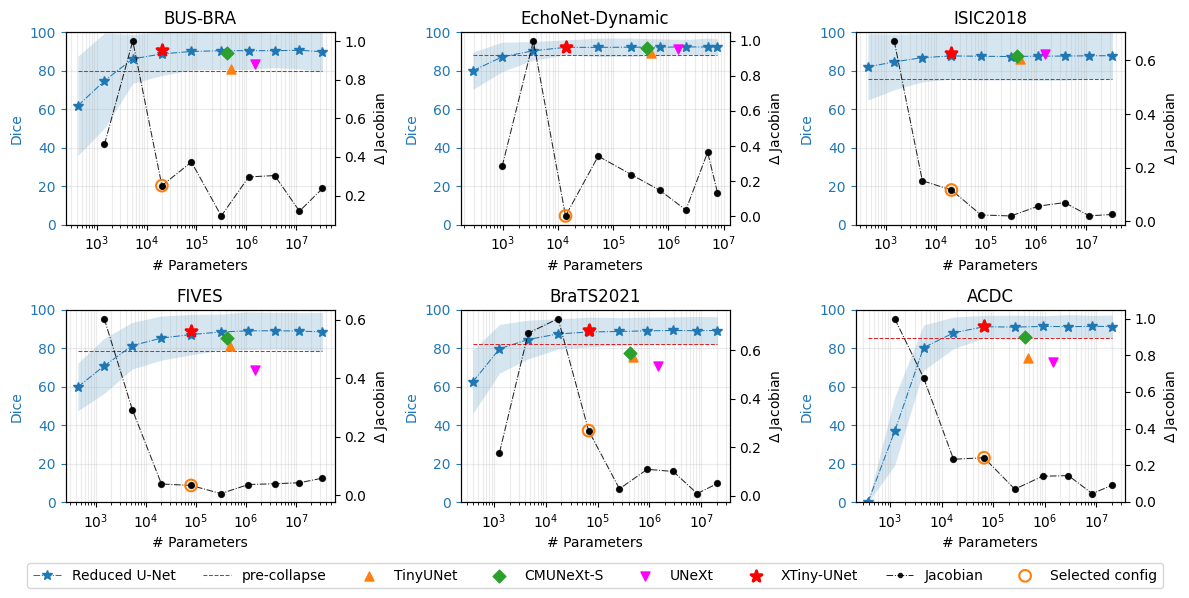

saved to results/analysis/jacobian_batches/jacobian_picks_l2agg_minmax_across_cfgs_tv_change_seed369.csv
saved to results/analysis/jacobian_batches/tv/jacobian_sim_bsall_l2agg_minmax_across_cfgs_tv_change_seed1.svg


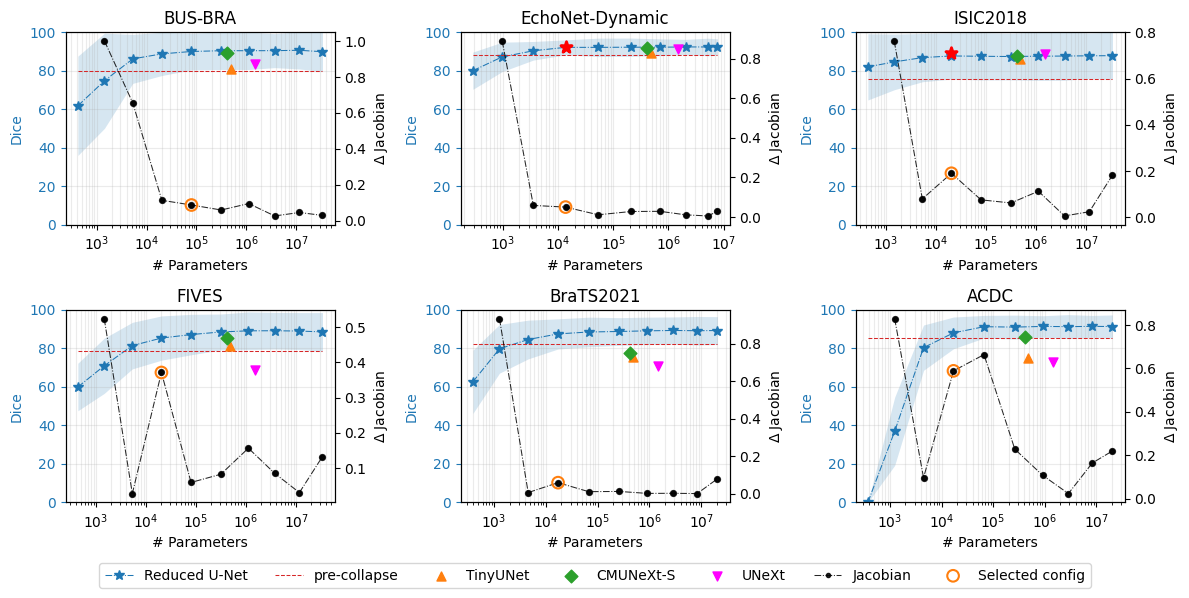

saved to results/analysis/jacobian_batches/jacobian_picks_l2agg_minmax_across_cfgs_tv_change_seed1.csv
saved to results/analysis/jacobian_batches/tv/jacobian_sim_bsall_l2agg_minmax_across_cfgs_tv_change_seed42.svg


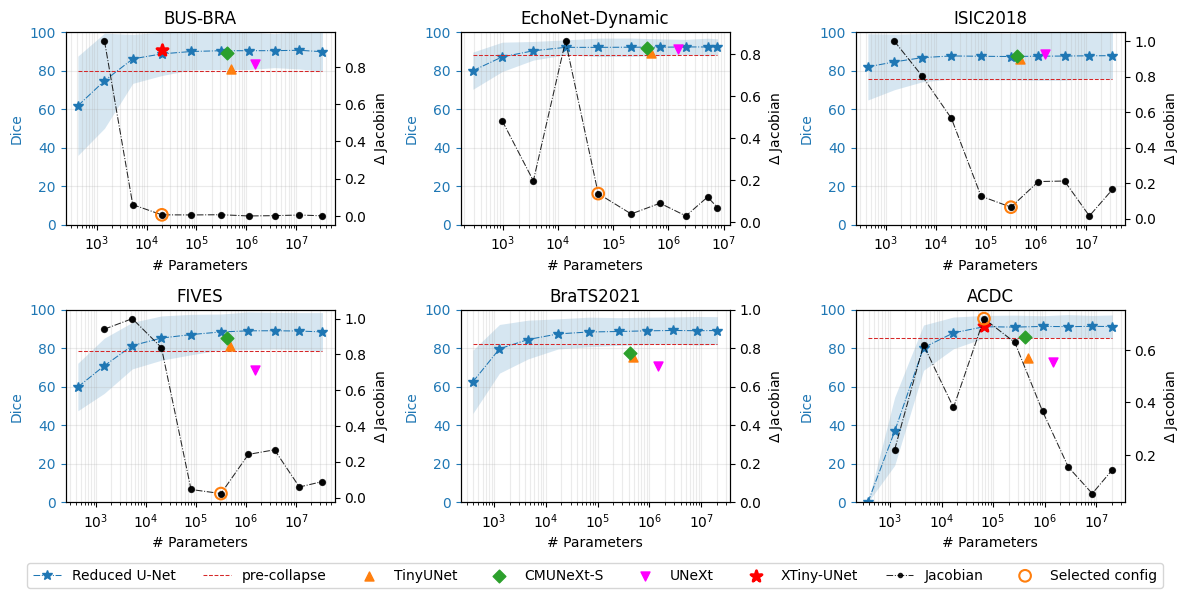

saved to results/analysis/jacobian_batches/jacobian_picks_l2agg_minmax_across_cfgs_tv_change_seed42.csv


In [25]:
# Settings
from scipy.interpolate import UnivariateSpline
cfgs = [
    "2d_tiny1",
    "2d_tiny2",
    "2d_tiny4",
    "2d_tiny8",
    "2d_tiny16",
    "2d_tiny32",
    "2d_tiny64",
    "2d_tiny128",
    "2d_tiny256",
    "2d",
]

baselines = ["TinyUNet", "CMUNeXt-S", "UNeXt"]
baseline_markers = ["^", "D", "v"]
baseline_colors = ["tab:orange", "tab:green", "magenta"]

dataset_ids = [
    301,
    302,
    300,
    309,
    137,
    306,
    # 304,
    # 305,
    # 308,
    # 137,
    # 312,
    # 310,
    # 307,
]

results_dir = "data/nnUNet_results/nnunet"
nnunet_raw = "data/nnUNet_raw"
nas_dir = "results/nas_metrics"
trainer = "nnUNetTrainer_100epochs"
plans = "nnUNetPlans"
fold = 0
encoder_only = False
source_batches = "all"  # read ..._batch_jacobian_b{source_batches}.csv
seeds = [369, 1, 42] #478] #, 42, 123, 80]
# seeds = [236, 111, 852, 456]
# seeds = [369, 1, 42, 478, 236, 111, 852, 456] #, 42, 123, 80]
# seeds = [36983, 72236, 123143, 309574, 370960, 455103, 483022, 662672, 862278, 965773]

# sim_batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, "all"]
# sim_batch_sizes = [32, 64, 128, "all"]
sim_batch_sizes = ["all"]
# sim_batch_sizes = ["32"]
use_relative_change = True
use_derivative = False 
 # if True with use_relative_change, use |d(jacobian)/d(log10(params))|
normalize_metric = False
jacobian_precollapse_rank = 1  # 1=last before collapse, 2=second-last
jacobian_pick_method = "tv"  # "tv" or "piecewise"
min_seg = 2
split_method = "two_line"  # "two_line", "avg_distance", or "combined"
combined_distance_weight = 0.25
plot_fit_lines = False
jacobian_spline_s = 0.05  # spline smoothing factor
use_jacobian_spline = False
plot_dice_fit_lines = False
include_hinge_in_both_lines = False

dice_plot_mode = "mean_std"  # "mean_std" or "box"
plot_std = True  # used when dice_plot_mode == "mean_std"
plot_2d_minus_1std_line = True  # used when dice_plot_mode == "mean_std"
box_ref_line_mode = "q1"  # "median_ci_low", "q1", "lower_whisker", "none"
box_showfliers = False

save_dir = "results/analysis/jacobian_batches"
os.makedirs(save_dir, exist_ok=True)

def get_box_reference_line(values, mode="median_ci_low"):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0 or mode == "none":
        return np.nan, None

    q1 = float(np.percentile(vals, 25))
    med = float(np.percentile(vals, 50))
    q3 = float(np.percentile(vals, 75))
    iqr = q3 - q1

    if mode == "q1":
        return q1, "Q1"
    if mode == "lower_whisker":
        lower_whisker = max(float(np.min(vals)), q1 - 1.5 * iqr)
        return lower_whisker, "lower whisker"
    if mode == "median_ci_low":
        # Approximate 95% CI lower bound for median used in notched boxplots.
        ci_half = 1.57 * iqr / np.sqrt(vals.size)
        return med - ci_half, "median 95% CI low"

    return np.nan, None

pick_rows = []

for selected_seed in seeds:
    for sim_bs in sim_batch_sizes:
        fig = plt.figure(figsize=(12, 8))

        for i, dataset_id in enumerate(dataset_ids):
            dataset_name = get_dataset_name(dataset_id, nnunet_raw)

            baseline_results = None
            if dataset_id in dataset_ids:
                baseline_results = get_baseline_results(
                    dataset_id,
                    baselines=baselines,
                    nnunet_raw=nnunet_raw,
                )
                missing = [
                    (m, baseline_results[m]["reason"])
                    for m in baselines
                    if not baseline_results[m].get("available", False)
                ]
                if missing:
                    for m, reason in missing:
                        print(f"warning: missing baseline for {dataset_name} - {m}: {reason}")

            params_map = {}
            dice_map = {}
            dice_std_map = {}
            dice_cases_map = {}
            for cfg in cfgs:
                m = get_dice(results_dir, dataset_name, trainer, plans, cfg, fold)
                params_map[cfg] = m["params"]
                dice_map[cfg] = m["dice"]
                dice_std_map[cfg] = m["dice_std"]
                dice_cases_map[cfg] = m.get("dice_cases", [])
            
            if encoder_only:
                batch_path = Path(nas_dir) / f"{dataset_name}_batch_jacobian_encoder_only_b{source_batches}.csv"
            else:
                batch_path = Path(nas_dir) / f"{dataset_name}_batch_jacobian_b{source_batches}.csv"
            if not os.path.exists(batch_path):
                continue

            df = pd.read_csv(batch_path)
            df = df[df["cfg"].isin(cfgs)]
            if selected_seed is not None and "seed" in df.columns:
                df = df[df["seed"] == selected_seed]

            vals_per_cfg = {}
            for cfg in cfgs:
                vals = df.loc[df["cfg"] == cfg, "jacobian"].astype(float).to_numpy()
                vals_per_cfg[cfg] = vals

            if sim_bs == "all":
                use_bs = "all"
            else:
                use_bs = int(sim_bs)

            jac_curve_raw = []
            for cfg in cfgs:
                vals = np.asarray(vals_per_cfg[cfg], dtype=float)
                # random.seed(random_seed)
                random.shuffle(vals)
                if use_bs != "all":
                    if len(vals) < use_bs:
                        jac_curve_raw.append(np.nan)
                        continue
                    vals = vals[:use_bs]
                if len(vals) == 0:
                    jac_curve_raw.append(np.nan)
                    continue
                # jac_curve_raw.append(batch_equivalent_l2(vals))
                jac_curve_raw.append(np.mean(vals))
            
            jac_curve_raw = np.asarray(jac_curve_raw, dtype=float)
            valid_raw = np.isfinite(jac_curve_raw)
            if np.any(valid_raw):
                jmin = np.nanmin(jac_curve_raw)
                jmax = np.nanmax(jac_curve_raw)
                if jmax > jmin:
                    jac_curve = ((jac_curve_raw - jmin) / (jmax - jmin)).tolist()
                else:
                    jac_curve = np.where(valid_raw, 0.0, np.nan).tolist()
            else:
                jac_curve = [np.nan] * len(jac_curve_raw)

            params_list = [params_map[cfg] for cfg in cfgs]
            dice_list = [dice_map[cfg] for cfg in cfgs]
            dice_std_list = [dice_std_map[cfg] for cfg in cfgs]
            dice_cases_list = [dice_cases_map[cfg] for cfg in cfgs]
            params_arr = np.asarray(params_list, dtype=float)
            dice_arr = np.asarray(dice_list, dtype=float)
            dice_std_arr = np.asarray(dice_std_list, dtype=float)

            jac_plot_curve = jac_curve
            if use_relative_change:
                if use_derivative:
                    jac_curve_arr = np.asarray(jac_curve, dtype=float)
                    jac_plot_arr = np.full_like(jac_curve_arr, np.nan, dtype=float)
                    valid_der = np.isfinite(jac_curve_arr) & np.isfinite(params_arr) & (params_arr > 0)
                    if np.sum(valid_der) >= 2:
                        x_der = np.log10(params_arr[valid_der])
                        # x_der = params_arr[valid_der]
                        y_der = jac_curve_arr[valid_der]
                        jac_plot_arr[valid_der] = np.abs(np.gradient(y_der, x_der))
                    jac_plot_curve = jac_plot_arr.tolist()
                else:
                    jac_plot_curve = [np.nan] + [abs(jac_curve[j] - jac_curve[j - 1]) for j in range(1, len(jac_curve))]

            if normalize_metric:
                valid = [x for x in jac_plot_curve if not np.isnan(x)]
                if len(valid) > 0 and (max(valid) - min(valid)) > 0:
                    jac_plot_curve = [np.nan if np.isnan(x) else (x - min(valid)) / (max(valid) - min(valid)) for x in jac_plot_curve]

            jac_arr = np.asarray(jac_plot_curve, dtype=float)

            jac_pick_index = None
            boundary_idx = None
            fit_info = None
            if jacobian_pick_method == "tv":
                jac_pick_index = knee_index_tv_slopes(params_arr, jac_arr, include_hinge_in_both_lines=include_hinge_in_both_lines)
            elif jacobian_pick_method == "piecewise":
                jac_pick_index, boundary_idx, fit_info = select_precollapse_config_from_jacobian(
                    params_list,
                    jac_plot_curve,
                    pre_collapse_rank=jacobian_precollapse_rank,
                    min_seg=min_seg,
                    method=split_method,
                    combined_distance_weight=combined_distance_weight,
                    include_hinge_in_both_lines=include_hinge_in_both_lines,
                )
            else:
                raise ValueError(f"Unknown jacobian_pick_method: {jacobian_pick_method}")

            pick_rows.append(
                {
                    "sim_batch_size": sim_bs,
                    "used_batch_size": use_bs,
                    "dataset": dataset_name,
                    "pick_method": jacobian_pick_method,
                    "encoder_only": encoder_only,
                    "selected_seed": selected_seed,
                    "jacobian_picked_cfg": cfgs[jac_pick_index] if jac_pick_index is not None else None,
                    "jacobian_picked_idx": jac_pick_index,
                    "boundary_idx": boundary_idx,
                }
            )

            plt.subplot(len(dataset_ids) // 2, 3, i + 1)
            ax = plt.gca()

            valid_dice_plot = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(dice_arr)

            if dice_plot_mode == "mean_std":
                label = "Reduced U-Net" if i == 0 else "_nolegend_"
                if np.any(valid_dice_plot):
                    if plot_dice_fit_lines:
                        ax.scatter(params_arr[valid_dice_plot], dice_arr[valid_dice_plot], marker="*", s=36, color="C0", label=label)
                    else:
                        ax.plot(params_arr[valid_dice_plot], dice_arr[valid_dice_plot], marker="*", linestyle="dashdot", linewidth=0.75, markersize=7, color="C0", label=label)

                if plot_std:
                    valid_std = valid_dice_plot & np.isfinite(dice_std_arr)
                    if np.any(valid_std):
                        x_std = params_arr[valid_std]
                        y_std = dice_arr[valid_std]
                        s_std = dice_std_arr[valid_std]
                        ax.fill_between(
                            x_std,
                            y_std - s_std,
                            y_std + s_std,
                            color="C0",
                            alpha=0.18,
                            linewidth=0,
                        )

                if plot_2d_minus_1std_line and "2d" in cfgs:
                    idx_2d = cfgs.index("2d")
                    if idx_2d < len(dice_arr) and idx_2d < len(dice_std_arr):
                        dice_2d = dice_arr[idx_2d]
                        std_2d = dice_std_arr[idx_2d]
                        if np.isfinite(dice_2d) and np.isfinite(std_2d):
                            line_y = dice_2d - std_2d
                            valid_params_line = np.isfinite(params_arr) & (params_arr > 0)
                            if np.any(valid_params_line):
                                x_pos = params_arr[valid_params_line]
                                line_label = "pre-collapse" if i == 0 else "_nolegend_"
                                ax.hlines(
                                    line_y,
                                    x_pos.min(),
                                    x_pos.max(),
                                    colors="tab:red",
                                    linestyles="dashed",
                                    linewidth=0.75,
                                    label=line_label,
                                )

            elif dice_plot_mode == "box":
                valid_box_idx = []
                for idx, cfg in enumerate(cfgs):
                    if not (np.isfinite(params_arr[idx]) and params_arr[idx] > 0):
                        continue
                    vals = np.asarray(dice_cases_list[idx], dtype=float)
                    vals = vals[np.isfinite(vals)]
                    if vals.size == 0:
                        continue
                    valid_box_idx.append(idx)

                if len(valid_box_idx) > 0:
                    positions = params_arr[valid_box_idx]
                    box_data = [np.asarray(dice_cases_list[idx], dtype=float) for idx in valid_box_idx]
                    widths = positions * (10 ** 0.06 - 10 ** -0.06)

                    bp = ax.boxplot(
                        box_data,
                        positions=positions,
                        widths=widths,
                        patch_artist=True,
                        manage_ticks=False,
                        showfliers=box_showfliers,
                    )
                    for patch in bp["boxes"]:
                        patch.set(facecolor="C0", alpha=0.18, edgecolor="C0", linewidth=0.8)
                    for med in bp["medians"]:
                        med.set(color="C0", linewidth=1.0)
                    for w in bp["whiskers"]:
                        w.set(color="C0", linewidth=0.8, alpha=0.8)
                    for cap in bp["caps"]:
                        cap.set(color="C0", linewidth=0.8, alpha=0.8)

                    # In box mode, do not overlay dice scatter/marker points.

                if "2d" in cfgs:
                    idx_2d = cfgs.index("2d")
                    vals_2d = np.asarray(dice_cases_list[idx_2d], dtype=float)
                    vals_2d = vals_2d[np.isfinite(vals_2d)]
                    line_y, line_desc = get_box_reference_line(vals_2d, mode=box_ref_line_mode)
                    valid_params_line = np.isfinite(params_arr) & (params_arr > 0)
                    if np.isfinite(line_y) and np.any(valid_params_line):
                        x_pos = params_arr[valid_params_line]
                        line_label = f"2d {line_desc}" if (i == 0 and line_desc is not None) else "_nolegend_"
                        ax.hlines(
                            line_y,
                            x_pos.min(),
                            x_pos.max(),
                            colors="tab:red",
                            linestyles="dashed",
                            linewidth=0.75,
                            label=line_label,
                        )
            else:
                raise ValueError(f"Unknown dice_plot_mode: {dice_plot_mode}")

            ax2 = ax.twinx()
            jlabel = "Jacobian" if i == 0 else "_nolegend_"
            valid_jac_plot = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(jac_arr)
            if np.any(valid_jac_plot):
                xj = np.log10(params_arr[valid_jac_plot])
                yj = jac_arr[valid_jac_plot]
                order = np.argsort(xj)
                xj = xj[order]
                yj = yj[order]

                # raw jacobian points
                ax2.scatter(10 ** xj, yj, marker="o", s=18, color="black", alpha=0.8, label="_nolegend_")

                # smoothed jacobian curve in log-parameter space
                if use_jacobian_spline and len(xj) >= 4:
                    try:
                        spline = UnivariateSpline(xj, yj, s=jacobian_spline_s)
                        x_fit = np.linspace(xj.min(), xj.max(), 200)
                        y_fit = spline(x_fit)
                        ax2.plot(10 ** x_fit, y_fit, marker="o", markersize=3, linestyle="dashdot", linewidth=0.9, color="black", alpha=0.85, label=jlabel)
                    except Exception:
                        ax2.plot(10 ** xj, yj, marker="o", markersize=3, linestyle="dashdot", linewidth=0.75, color="black", alpha=0.85, label=jlabel)
                else:
                    ax2.plot(10 ** xj, yj, marker="o", markersize=3, linestyle="dashdot", linewidth=0.75, color="black", alpha=0.85, label=jlabel)

            if fit_info is not None:
                bl = fit_info["boundary_left_idx"]
                br = fit_info["boundary_right_idx"]
                if np.isfinite(params_arr[bl]) and np.isfinite(params_arr[br]) and params_arr[bl] > 0 and params_arr[br] > 0:
                    split_x = 10 ** ((np.log10(params_arr[bl]) + np.log10(params_arr[br])) / 2.0)
                    split_label = "split b|b+1" if i == 0 else "_nolegend_"
                    ax2.axvline(split_x, color="tab:red", linestyle=":", linewidth=1.0, alpha=0.9, label=split_label)

            if baseline_results is not None:
                for b, baseline_model in enumerate(baselines):
                    if not baseline_results[baseline_model].get("available", False):
                        continue
                    b_dice = baseline_results[baseline_model]["dice"]
                    b_params = baseline_results[baseline_model]["params"]
                    if not (np.isfinite(b_dice) and np.isfinite(b_params) and b_params > 0):
                        continue
                    blabel = baseline_model if i == 0 else "_nolegend_"
                    ax.scatter(
                        b_params,
                        b_dice,
                        marker=baseline_markers[b % len(baseline_markers)],
                        color=baseline_colors[b % len(baseline_colors)],
                        s=42,
                        zorder=6,
                        label=blabel,
                    )

            if jac_pick_index is not None and np.isfinite(params_arr[jac_pick_index]) and params_arr[jac_pick_index] > 0:
                picked_cfg = cfgs[jac_pick_index]

                # Plot XTiny point from nnUNetTrainer chosen-config results (strict, no fallback).
                xtiny_metrics = get_dice(
                    results_dir,
                    dataset_name,
                    "nnUNetTrainer",
                    plans,
                    picked_cfg,
                    fold,
                    allow_validation_fallback=False,
                )
                # x from picked config on the main (100epochs) curve; y from nnUNetTrainer result.
                xtiny_params = float(params_arr[jac_pick_index]) if np.isfinite(params_arr[jac_pick_index]) else np.nan
                xtiny_dice = float(xtiny_metrics["dice"]) if pd.notna(xtiny_metrics["dice"]) else np.nan

                xtiny_label = "XTiny-UNet" if i == 0 else "_nolegend_"
                if np.isfinite(xtiny_params) and xtiny_params > 0 and np.isfinite(xtiny_dice):
                    ax.scatter(
                        xtiny_params,
                        xtiny_dice,
                        marker="*",
                        s=70,
                        c="red",
                        linewidths=2.0,
                        zorder=7,
                        label=xtiny_label,
                    )

                jac_pick_label = "Selected config" if i == 0 else "_nolegend_"
                if np.isfinite(jac_arr[jac_pick_index]):
                    ax2.scatter(
                        params_arr[jac_pick_index],
                        jac_arr[jac_pick_index],
                        marker="o",
                        s=70,
                        facecolors="none",
                        edgecolors="tab:orange",
                        linewidths=1.5,
                        zorder=7,
                        label=jac_pick_label,
                    )

            drop_label = "1% drop" if i == 0 else "_nolegend_"
            valid_dice = dice_arr[np.isfinite(dice_arr)]
            valid_params = params_arr[np.isfinite(params_arr) & (params_arr > 0)]
            # if len(valid_dice) > 0 and len(valid_params) > 0:
            #     drop_y = valid_dice[-1] * (1 - 0.02)
            #     ax.hlines(drop_y, valid_params.min(), valid_params.max(), colors="red", linestyles="dashed", linewidth=0.75, label=drop_label)

            ax.set_xlabel("# Parameters")
            ax.set_ylabel("Dice", color="C0")
            ax.tick_params(axis="y", colors="C0")
            y_base = (r"|d Jacobian / d log10(params)|" if use_derivative else r"$\Delta$ Jacobian") if use_relative_change else "Normalized Jacobian"
            y_norm = " (min-max)" if normalize_metric else ""
            ax2.set_ylabel(f"{y_base}") #{y_norm}, bs={use_bs}")
            # ax2.invert_yaxis()
            title = dataset_name.split('_')[1]
            if title == "isic2018":
                title = title.upper()
            if title == "busbra":
                title = "BUS-BRA"
            ax.set_title(f"{title}")
            if len(valid_params) > 0:
                ax.set_xscale("log")
                # Show both major and minor vertical gridlines in log scale.
                ax.grid(which="major", axis="x", alpha=0.25, linestyle="-")
                ax.grid(which="minor", axis="x", alpha=0.25, linestyle="-")
            ax.grid(which="major", axis="y", alpha=0.25, linestyle="-")
            ax.set_ylim(0, 100)
            # ax2.set_ylim(0, 1)

            # print(f"{dataset_name}: jacobian pick method={jacobian_pick_method}, index={jac_pick_index}")

        fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.25), ncol=8)
        plt.tight_layout()

        suffix = "_derivative" if (use_relative_change and use_derivative) else ("_change" if use_relative_change else "")
        if normalize_metric:
            suffix += "_norm"
        if selected_seed is not None:
            suffix += f"_seed{selected_seed}"
        if encoder_only:
            suffix += "_encoder_only"
        jacobian_pick_tag = split_method if jacobian_pick_method == "piecewise" else "tv"
        os.makedirs(f"{save_dir}/{jacobian_pick_tag}", exist_ok=True)
        out_path = f"{save_dir}/{jacobian_pick_tag}/jacobian_sim_bs{use_bs}_l2agg_minmax_across_cfgs_{jacobian_pick_tag}{suffix}.svg"
        plt.savefig(out_path, dpi=300, bbox_inches="tight", format='svg')
        print(f"saved to {out_path}")
        plt.show()

    pick_df = pd.DataFrame(pick_rows)
    suffix = "_derivative" if (use_relative_change and use_derivative) else ("_change" if use_relative_change else "")
    if normalize_metric:
        suffix += "_norm"
    if selected_seed is not None:
        suffix += f"_seed{selected_seed}"
    if encoder_only:
        suffix += "_encoder_only"
    jacobian_pick_tag = split_method if jacobian_pick_method == "piecewise" else "tv"
    pick_csv = f"{save_dir}/jacobian_picks_l2agg_minmax_across_cfgs_{jacobian_pick_tag}{suffix}.csv"
    pick_df.to_csv(pick_csv, index=False)
    print(f"saved to {pick_csv}")
    pick_df

Figures will be saved to: /home/ultrai/UltrAi/nntinyunet/results/analysis/jacobian_batches/diagnostics_all_datasets
Plotting dataset: Dataset301_busbra (id=301)
  Initialization seeds used: [1, 42, 80, 123, 369, 478]
  saved: results/analysis/jacobian_batches/diagnostics_all_datasets/Dataset301_busbra_diagnostics_1x3.svg


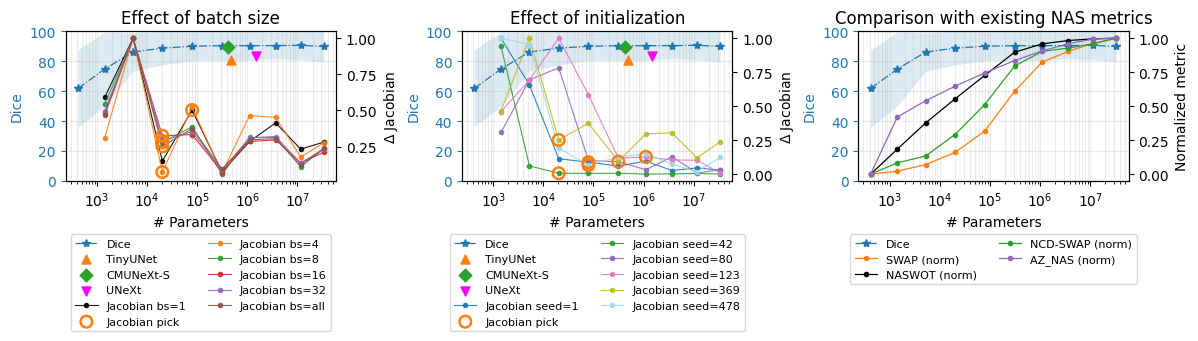

Plotting dataset: Dataset302_EchoNet-Dynamic (id=302)
  Initialization seeds used: [1, 42, 80, 123, 236, 369, 478]
  saved: results/analysis/jacobian_batches/diagnostics_all_datasets/Dataset302_EchoNet-Dynamic_diagnostics_1x3.svg


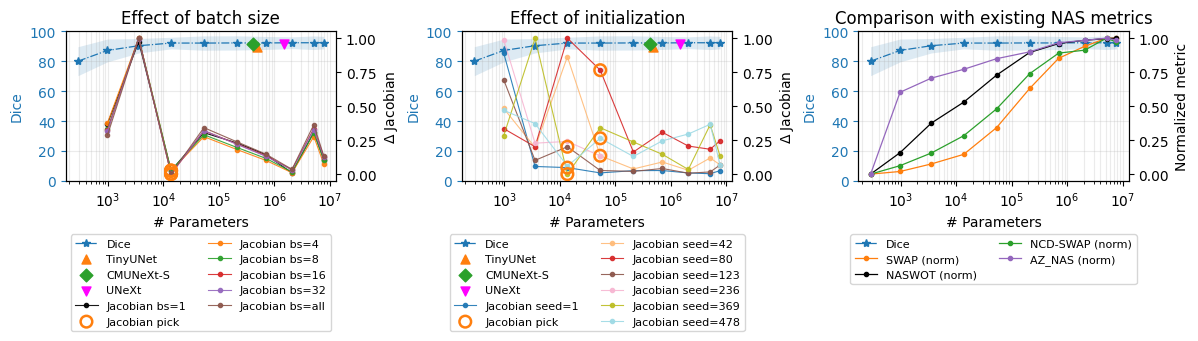

Plotting dataset: Dataset300_isic2018 (id=300)
  Initialization seeds used: [1, 42, 80, 123, 369, 478]
  saved: results/analysis/jacobian_batches/diagnostics_all_datasets/Dataset300_isic2018_diagnostics_1x3.svg


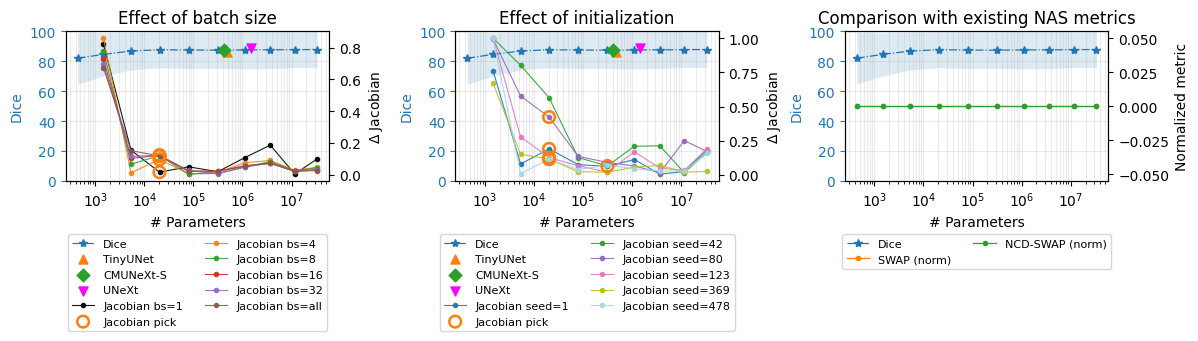

Plotting dataset: Dataset309_FIVES (id=309)
  Initialization seeds used: [1, 42, 80, 123, 369, 478]
  saved: results/analysis/jacobian_batches/diagnostics_all_datasets/Dataset309_FIVES_diagnostics_1x3.svg


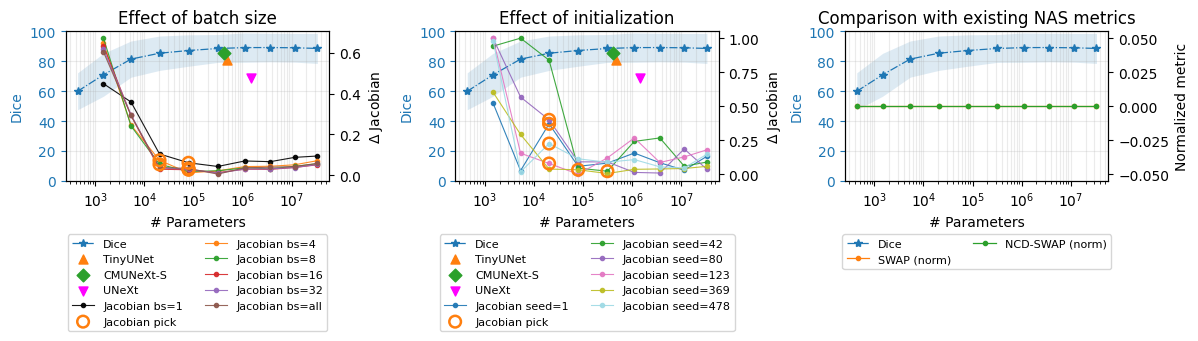

Plotting dataset: Dataset137_BraTS2021 (id=137)
  Initialization seeds used: [1, 80, 123, 369, 478]
  saved: results/analysis/jacobian_batches/diagnostics_all_datasets/Dataset137_BraTS2021_diagnostics_1x3.svg


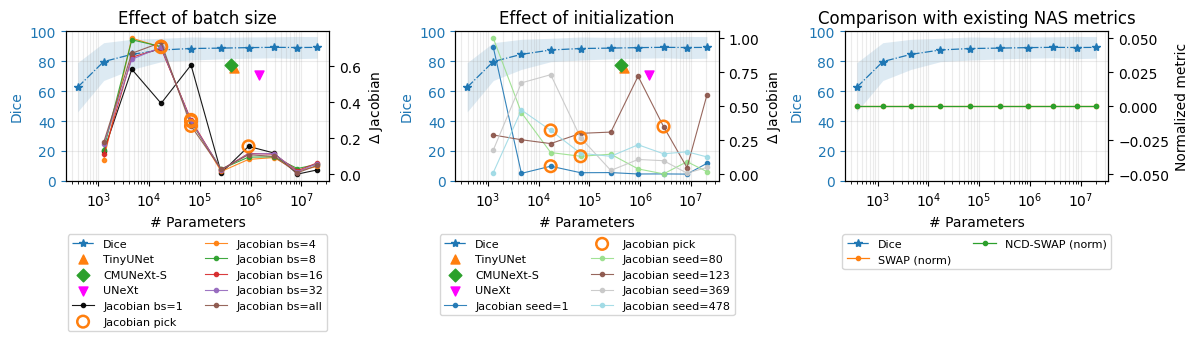

Plotting dataset: Dataset306_ACDC (id=306)
  Initialization seeds used: [1, 42, 80, 123, 369, 478]
  saved: results/analysis/jacobian_batches/diagnostics_all_datasets/Dataset306_ACDC_diagnostics_1x3.svg


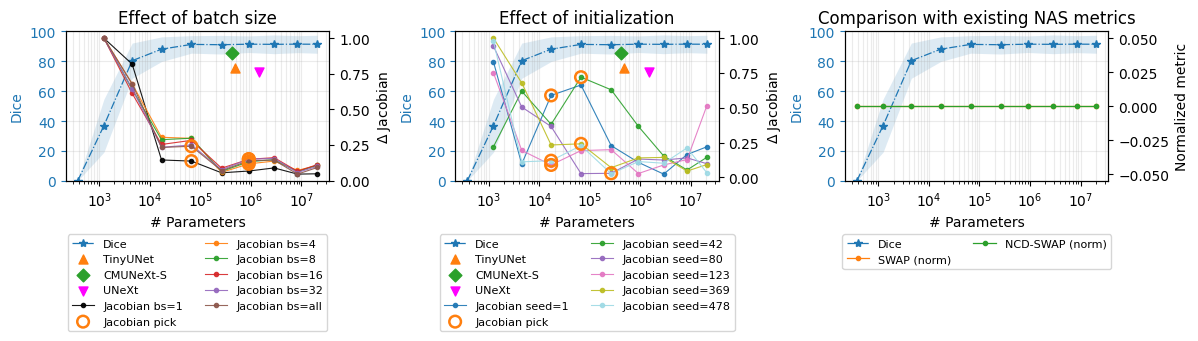

In [26]:
# 1x3 diagnostics for all datasets in dataset_ids (same style as the EchoNet cell)


def _safe_minmax(arr):
    arr = np.asarray(arr, dtype=float)
    out = np.full_like(arr, np.nan, dtype=float)
    valid = np.isfinite(arr)
    if np.any(valid):
        amin = np.nanmin(arr)
        amax = np.nanmax(arr)
        if amax > amin:
            out[valid] = (arr[valid] - amin) / (amax - amin)
        else:
            out[valid] = 0.0
    return out


def _load_params_dice_and_std(dataset_name):
    p_list, d_list, ds_list = [], [], []
    for c in cfgs:
        m = get_dice(results_dir, dataset_name, trainer, plans, c, fold)
        p_list.append(m['params'])
        d_list.append(m['dice'])
        ds_list.append(m['dice_std'])
    return np.asarray(p_list, dtype=float), np.asarray(d_list, dtype=float), np.asarray(ds_list, dtype=float)


def _batch_jacobian_path(dataset_name):
    sb = str(source_batches)
    if encoder_only:
        return Path(nas_dir) / f"{dataset_name}_batch_jacobian_encoder_only_b{sb}.csv"
    return Path(nas_dir) / f"{dataset_name}_batch_jacobian_b{sb}.csv"


def _jacobian_curve_for_seed_and_bs(dataset_name, seed, use_bs):
    path = _batch_jacobian_path(dataset_name)
    if not path.exists():
        return None

    df = pd.read_csv(path)
    df = df[df['cfg'].isin(cfgs)]
    if 'seed' in df.columns:
        df = df[df['seed'] == int(seed)]

    raw = []
    for c in cfgs:
        vals = df.loc[df['cfg'] == c, 'jacobian'].astype(float).to_numpy()
        vals = np.asarray(vals, dtype=float)

        if use_bs != 'all':
            if len(vals) < int(use_bs):
                raw.append(np.nan)
                continue
            rr = np.random.default_rng(0)
            vals = vals.copy()
            rr.shuffle(vals)
            vals = vals[: int(use_bs)]

        raw.append(float(np.mean(vals)) if len(vals) > 0 else np.nan)

    raw = np.asarray(raw, dtype=float)
    jac_curve = _safe_minmax(raw)

    if use_relative_change and not use_derivative:
        jc = jac_curve.tolist()
        jac_plot = [np.nan] + [abs(jc[j] - jc[j - 1]) for j in range(1, len(jc))]
        jac_plot = np.asarray(jac_plot, dtype=float)
    else:
        jac_plot = np.asarray(jac_curve, dtype=float)

    if normalize_metric:
        jac_plot = _safe_minmax(jac_plot)

    return jac_plot


def _metrics_curve(dataset_name, seed, batches='all', metric='naswot'):
    path = Path(nas_dir) / f"{dataset_name}_metrics_b{batches}_seed{seed}.csv"
    if not path.exists():
        cands = sorted(Path(nas_dir).glob(f"{dataset_name}_metrics_b{batches}_seed*.csv"))
        if not cands:
            return None
        path = cands[0]

    df = pd.read_csv(path)
    if metric not in df.columns:
        return None

    vals = []
    for c in cfgs:
        sub = df[df['cfg'] == c]
        vals.append(float(sub.iloc[0][metric]) if len(sub) else np.nan)
    return _safe_minmax(np.asarray(vals, dtype=float))


plot_dataset_ids = dataset_ids[:]
batch_seed = 369
batch_sizes = [1, 4, 8, 16, 32, 'all']
nas_metric_seed = 369
nas_metric_batch = '32'

diag_save_dir = Path(save_dir) / 'diagnostics_all_datasets'
diag_save_dir.mkdir(parents=True, exist_ok=True)
print(f'Figures will be saved to: {diag_save_dir.resolve()}')

for _did in plot_dataset_ids:
    _dname = get_dataset_name(_did, nnunet_raw)
    print(f'Plotting dataset: {_dname} (id={_did})')
    _bpath = _batch_jacobian_path(_dname)
    if _bpath.exists():
        _tmp = pd.read_csv(_bpath)
        if 'seed' in _tmp.columns:
            seed_sweep = sorted(pd.to_numeric(_tmp['seed'], errors='coerce').dropna().astype(int).unique().tolist())
        else:
            seed_sweep = [batch_seed]
    else:
        seed_sweep = [batch_seed]
    print(f'  Initialization seeds used: {seed_sweep}')
    params_arr, dice_arr, dice_std_arr = _load_params_dice_and_std(_dname)

    baseline_results = get_baseline_results(_did, baselines=baselines, nnunet_raw=nnunet_raw)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.8), sharex=True)
    ax0, ax1, ax2 = axes
    ax0r = ax0.twinx()
    ax1r = ax1.twinx()
    ax2r = ax2.twinx()

    valid_dice = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(dice_arr)
    valid_dice_std = valid_dice & np.isfinite(dice_std_arr)

    pick_marker_color = 'tab:orange'
    pick_label_added_col1 = False
    pick_label_added_col2 = False

    # -------- Col 1: Effect of batch size --------
    if np.any(valid_dice):
        ax0.plot(params_arr[valid_dice], dice_arr[valid_dice], marker='*', linestyle='dashdot', linewidth=0.9, color='C0', label='Dice')
    if np.any(valid_dice_std):
        ax0.fill_between(
            params_arr[valid_dice_std],
            dice_arr[valid_dice_std] - dice_std_arr[valid_dice_std],
            dice_arr[valid_dice_std] + dice_std_arr[valid_dice_std],
            color='C0', alpha=0.15, linewidth=0, label='_nolegend_'
        )

    for b, baseline_model in enumerate(baselines):
        if not baseline_results[baseline_model].get('available', False):
            continue
        b_dice = baseline_results[baseline_model].get('dice', np.nan)
        b_params = baseline_results[baseline_model].get('params', np.nan)
        if np.isfinite(b_dice) and np.isfinite(b_params) and b_params > 0:
            ax0.scatter(
                b_params,
                b_dice,
                marker=baseline_markers[b % len(baseline_markers)],
                color=baseline_colors[b % len(baseline_colors)],
                s=42,
                zorder=6,
                label=baseline_model,
            )

    bs_colors = ['k', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
    for bs, col in zip(batch_sizes, bs_colors):
        jac = _jacobian_curve_for_seed_and_bs(_dname, batch_seed, bs)
        if jac is None:
            continue
        valid = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(jac)
        if np.any(valid):
            ax0r.plot(params_arr[valid], jac[valid], marker='o', markersize=3, linestyle='-', linewidth=0.8, color=col, alpha=0.9, label=f'Jacobian bs={bs}')

            pick_idx = knee_index_tv_slopes(params_arr, jac, include_hinge_in_both_lines=include_hinge_in_both_lines)
            if pick_idx is not None and np.isfinite(jac[pick_idx]) and np.isfinite(params_arr[pick_idx]) and params_arr[pick_idx] > 0:
                ax0r.scatter(
                    params_arr[pick_idx],
                    jac[pick_idx],
                    marker='o',
                    s=70,
                    facecolors='none',
                    edgecolors=pick_marker_color,
                    linewidths=1.8,
                    zorder=8,
                    label='Jacobian pick' if not pick_label_added_col1 else '_nolegend_'
                )
                pick_label_added_col1 = True

    ax0.set_title('Effect of batch size')
    ax0.set_xlabel('# Parameters')
    ax0.set_ylabel('Dice', color='C0')
    ax0.tick_params(axis='y', colors='C0')
    ax0r.set_ylabel(r'$\Delta$ Jacobian')

    # -------- Col 2: Effect of initialization --------
    if np.any(valid_dice):
        ax1.plot(params_arr[valid_dice], dice_arr[valid_dice], marker='*', linestyle='dashdot', linewidth=0.9, color='C0', label='Dice')
    if np.any(valid_dice_std):
        ax1.fill_between(
            params_arr[valid_dice_std],
            dice_arr[valid_dice_std] - dice_std_arr[valid_dice_std],
            dice_arr[valid_dice_std] + dice_std_arr[valid_dice_std],
            color='C0', alpha=0.15, linewidth=0, label='_nolegend_'
        )

    for b, baseline_model in enumerate(baselines):
        if not baseline_results[baseline_model].get('available', False):
            continue
        b_dice = baseline_results[baseline_model].get('dice', np.nan)
        b_params = baseline_results[baseline_model].get('params', np.nan)
        if np.isfinite(b_dice) and np.isfinite(b_params) and b_params > 0:
            ax1.scatter(
                b_params,
                b_dice,
                marker=baseline_markers[b % len(baseline_markers)],
                color=baseline_colors[b % len(baseline_colors)],
                s=42,
                zorder=6,
                label=baseline_model,
            )

    seed_colors = plt.cm.tab20(np.linspace(0, 1, max(len(seed_sweep), 1)))
    for sd, col in zip(seed_sweep, seed_colors):
        jac = _jacobian_curve_for_seed_and_bs(_dname, sd, 'all')
        if jac is None:
            continue
        valid = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(jac)
        if np.any(valid):
            ax1r.plot(params_arr[valid], jac[valid], marker='o', markersize=3, linestyle='-', linewidth=0.8, color=col, alpha=0.9, label=f'Jacobian seed={sd}')

            pick_idx = knee_index_tv_slopes(params_arr, jac, include_hinge_in_both_lines=include_hinge_in_both_lines)
            if pick_idx is not None and np.isfinite(jac[pick_idx]) and np.isfinite(params_arr[pick_idx]) and params_arr[pick_idx] > 0:
                ax1r.scatter(
                    params_arr[pick_idx],
                    jac[pick_idx],
                    marker='o',
                    s=70,
                    facecolors='none',
                    edgecolors=pick_marker_color,
                    linewidths=1.8,
                    zorder=8,
                    label='Jacobian pick' if not pick_label_added_col2 else '_nolegend_'
                )
                pick_label_added_col2 = True

    ax1.set_title('Effect of initialization')
    ax1.set_xlabel('# Parameters')
    ax1.set_ylabel('Dice', color='C0')
    ax1.tick_params(axis='y', colors='C0')
    ax1r.set_ylabel(r'$\Delta$ Jacobian')

    # -------- Col 3: Comparison with existing NAS metrics --------
    if np.any(valid_dice):
        ax2.plot(params_arr[valid_dice], dice_arr[valid_dice], marker='*', linestyle='dashdot', linewidth=0.9, color='C0', label='Dice')
    if np.any(valid_dice_std):
        ax2.fill_between(
            params_arr[valid_dice_std],
            dice_arr[valid_dice_std] - dice_std_arr[valid_dice_std],
            dice_arr[valid_dice_std] + dice_std_arr[valid_dice_std],
            color='C0', alpha=0.15, linewidth=0, label='_nolegend_'
        )

    metric_specs = [
        ('swap', 'SWAP (norm)', 'tab:orange'),
        ('naswot', 'NASWOT (norm)', 'k'),
        ('ncd_swap', 'NCD-SWAP (norm)', 'tab:green'),
        ('ncd_naswot', 'NCD-NASWOT (norm)', 'tab:red'),
        ('az_nas', 'AZ_NAS (norm)', 'tab:purple'),
    ]
    for mkey, mlabel, mcolor in metric_specs:
        mvals = _metrics_curve(_dname, nas_metric_seed, batches=nas_metric_batch, metric=mkey)
        if mvals is None:
            continue
        valid = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(mvals)
        if np.any(valid):
            ax2r.plot(params_arr[valid], mvals[valid], marker='o', markersize=3, linestyle='-', linewidth=0.9, color=mcolor, label=mlabel)

    ax2.set_title('Comparison with existing NAS metrics')
    ax2.set_xlabel('# Parameters')
    ax2.set_ylabel('Dice', color='C0')
    ax2.tick_params(axis='y', colors='C0')
    ax2r.set_ylabel('Normalized metric')

    for a in axes:
        a.set_xscale('log')
        a.grid(which='major', axis='x', alpha=0.25, linestyle='-')
        a.grid(which='minor', axis='x', alpha=0.25, linestyle='-')
        a.grid(which='major', axis='y', alpha=0.25, linestyle='-')
        a.set_ylim(0, 100)

    for a, ar in [(ax0, ax0r), (ax1, ax1r), (ax2, ax2r)]:
        h1, l1 = a.get_legend_handles_labels()
        h2, l2 = ar.get_legend_handles_labels()
        handles, labels = [], []
        for h, l in list(zip(h1, l1)) + list(zip(h2, l2)):
            if l == '_nolegend_' or l in labels:
                continue
            handles.append(h)
            labels.append(l)
        if labels:
            a.legend(
                handles,
                labels,
                loc='upper center',
                bbox_to_anchor=(0.5, -0.32),
                ncol=2,
                fontsize=8,
                frameon=True,
            )

    plt.tight_layout(rect=[0, 0.12, 1, 1])
    out_path = diag_save_dir / f"{_dname}_diagnostics_1x3.svg"
    plt.savefig(out_path, format='svg', bbox_inches='tight', pad_inches=0)
    print(f"  saved: {out_path}")
    plt.show()


In [27]:
# Table 1 / Table 2 summary tables (auto-filled from available results)
import json
from pathlib import Path
from IPython.display import display

NNUNET_RAW = "data/nnUNet_raw"
PICKS_DIR = Path("results/analysis/jacobian_batches")
PICKS_CSV = None  # set explicit file path string to pin a specific picks csv
PICKED_SEED = 369  # set int to filter selected_seed; None keeps all (latest row per dataset)

BASELINE_MODEL_DIRS = {
    "TinyUNet": Path("/home/ultrai/UltrAi/UNeXt/models/TinyUNet"),
    "CMUNeXt-S": Path("/home/ultrai/UltrAi/CMUNeXt/models/CMUNeXt-S"),
    "UNeXt-S": Path("/home/ultrai/UltrAi/UNeXt/models/UNext_S"),
    "UNeXt": Path("/home/ultrai/UltrAi/UNeXt/models/UNext"),
    "Med_NCA": Path("/home/ultrai/UltrAi/Med-NCA/models"),
}

# Build baseline specs from notebook-level `baselines` when available.
_baseline_names = baselines if 'baselines' in globals() else ["TinyUNet", "CMUNeXt-S", "UNeXt-S"]
MODEL_SPECS = {}
for _name in _baseline_names:
    if _name in BASELINE_MODEL_DIRS:
        MODEL_SPECS[_name] = {
            "base": BASELINE_MODEL_DIRS[_name],
            "kind": "baseline",
        }

# Toggle Med_NCA without deleting config.
ENABLE_MED_NCA = False
if ENABLE_MED_NCA and "Med_NCA" in BASELINE_MODEL_DIRS and "Med_NCA" not in MODEL_SPECS:
    MODEL_SPECS["Med_NCA"] = {
        "base": BASELINE_MODEL_DIRS["Med_NCA"],
        "kind": "baseline",
    }

# Add chosen-config and fixed nnU-Net rows.
MODEL_SPECS["XTinyU-Net"] = {
    "base": Path("data/nnUNet_results/nnunet"),
    "kind": "xtiny",
    "trainer": "nnUNetTrainer",
    "plans": "nnUNetPlans",
}
MODEL_SPECS["nnU-Net"] = {
    "base": Path("data/nnUNet_results/nnunet"),
    "kind": "nnunet_fixed",
    "trainer": "nnUNetTrainer_100epochs",
    "plans": "nnUNetPlans",
    "cfg": "2d",
}


MODEL_ORDER = [
    "UNeXt",
    "CMUNeXt-S",
    "TinyUNet",
    "XTinyU-Net",
    "nnU-Net",
]

TABLES = {
    "Table 1. Quantitative results": [
        ("BUS-BRA", [301]),
        ("EchoNet Dynamic", [302]),
        ("ISIC2018", [300]),
    ],
    "Table 2. Quantitative results": [
        ("FIVES", [309]),
        ("BraTS2021", [137]),  # use same BraTS dataset as plotting cell
        ("ACDC", [306]),
    ],
}


def _resolve_dataset_name(candidate_ids):
    for did in candidate_ids:
        try:
            return get_dataset_name(did, NNUNET_RAW)
        except Exception:
            continue
    return None


def _pick_file_path():
    if PICKS_CSV is not None:
        p = Path(PICKS_CSV)
        return p if p.exists() else None
    files = sorted(PICKS_DIR.glob("jacobian_picks*.csv"), key=lambda p: p.stat().st_mtime)
    return files[-1] if files else None


def _load_picked_cfg_map():
    p = _pick_file_path()
    if p is None:
        return {}, None

    df = pd.read_csv(p)
    if df.empty or "dataset" not in df.columns or "jacobian_picked_cfg" not in df.columns:
        return {}, p

    if "selected_seed" in df.columns and PICKED_SEED is not None:
        df = df[df["selected_seed"] == PICKED_SEED]

    if "sim_batch_size" in df.columns:
        df = df[df["sim_batch_size"].astype(str) == "all"]
    if "used_batch_size" in df.columns:
        df = df[df["used_batch_size"].astype(str) == "all"]

    # Keep latest row per dataset in file order.
    cfg_map = {}
    for _, r in df.iterrows():
        d = str(r.get("dataset", ""))
        c = str(r.get("jacobian_picked_cfg", ""))
        if d and c and c != "nan":
            cfg_map[d] = c

    return cfg_map, p


def _read_test_metrics(results_csv, dataset_name):
    df = pd.read_csv(results_csv)
    if df.empty:
        return np.nan, np.nan, np.nan, np.nan

    if "test_dataset_name" in df.columns:
        df_sel = df[df["test_dataset_name"] == dataset_name]
        if df_sel.empty:
            df_sel = df
    else:
        df_sel = df

    row = df_sel.iloc[-1]
    dice = float(row["dice"]) if "dice" in row.index and pd.notna(row["dice"]) else np.nan
    dice_std = float(row["dice_std"]) if "dice_std" in row.index and pd.notna(row["dice_std"]) else np.nan
    hd95 = float(row["hd95"]) if "hd95" in row.index and pd.notna(row["hd95"]) else np.nan
    hd95_std = float(row["hd95_std"]) if "hd95_std" in row.index and pd.notna(row["hd95_std"]) else np.nan
    return dice, dice_std, hd95, hd95_std


def _read_val_metrics(summary_json):
    with open(summary_json, "r") as f:
        s = json.load(f)
    fg = s.get("foreground_mean", {})

    dice = fg.get("Dice", np.nan)
    hd95 = fg.get("HD95", fg.get("Hausdorff Distance 95", np.nan))

    if pd.notna(dice):
        dice = float(dice)
        if dice <= 1.0:
            dice *= 100.0

    if pd.notna(hd95):
        hd95 = float(hd95)

    dice_vals = []
    hd95_vals = []
    for case in s.get("metric_per_case", []):
        case_metrics = case.get("metrics", {})
        class_key = next(iter(case_metrics), None)
        if class_key is None:
            continue
        m = case_metrics.get(class_key, {})
        d = m.get("Dice")
        h = m.get("HD95", m.get("Hausdorff Distance 95"))
        if d is not None and pd.notna(d):
            d = float(d)
            if d <= 1.0:
                d *= 100.0
            dice_vals.append(d)
        if h is not None and pd.notna(h):
            hd95_vals.append(float(h))

    dice_std = float(np.std(np.asarray(dice_vals, dtype=float))) if len(dice_vals) > 0 else np.nan
    hd95_std = float(np.std(np.asarray(hd95_vals, dtype=float))) if len(hd95_vals) > 0 else np.nan

    return dice, dice_std, hd95, hd95_std


def _xtiny_cfg_for_dataset(dataset_name):
    return PICKED_CFG_MAP.get(dataset_name)


def _model_dir(spec, dataset_name):
    if spec["kind"] == "xtiny":
        cfg = _xtiny_cfg_for_dataset(dataset_name)
        if cfg is None or str(cfg).strip() == "":
            return None
        return spec["base"] / dataset_name / f"{spec['trainer']}__{spec['plans']}__{cfg}"
    if spec["kind"] == "nnunet_fixed":
        cfg = spec.get("cfg")
        if cfg is None or str(cfg).strip() == "":
            return None
        return spec["base"] / dataset_name / f"{spec['trainer']}__{spec['plans']}__{cfg}"
    return spec["base"] / dataset_name


def get_model_metrics(model_name, dataset_name):
    spec = MODEL_SPECS[model_name]
    if dataset_name is None:
        return np.nan, np.nan, np.nan, np.nan

    model_dir = _model_dir(spec, dataset_name)
    if model_dir is None:
        return np.nan, np.nan, np.nan, np.nan

    test_csv = model_dir / "fold_0" / "test" / "results.csv"
    if test_csv.exists():
        return _read_test_metrics(test_csv, dataset_name)

    # For XTiny chosen configs, do not fallback if nnUNetTrainer test results are absent.
    if spec["kind"] == "xtiny":
        return np.nan, np.nan, np.nan, np.nan

    val_summary = model_dir / "fold_0" / "validation" / "summary.json"
    if val_summary.exists():
        return _read_val_metrics(val_summary)

    return np.nan, np.nan, np.nan, np.nan


def _read_complexity(model_dir):
    if model_dir is None:
        return np.nan, np.nan
    analysis_path = model_dir / "model_analysis.json"
    if not analysis_path.exists():
        return np.nan, np.nan

    with open(analysis_path, "r") as f:
        m = json.load(f)

    params = m.get("parameters", {}).get("total", np.nan)
    flops = m.get("flops", {}).get("total", np.nan)
    params_k = float(params) / 1e3 if pd.notna(params) else np.nan
    flops_g = float(flops) / 1e9 if pd.notna(flops) else np.nan
    return params_k, flops_g


def get_model_complexity_k_g(model_name, table_dataset_names):
    spec = MODEL_SPECS[model_name]

    vals = []
    for ds in table_dataset_names:
        if ds is None:
            continue
        model_dir = _model_dir(spec, ds)
        pk, fg = _read_complexity(model_dir)
        if pd.notna(pk) and pd.notna(fg):
            vals.append((pk, fg))

    if not vals:
        return "-", "-"

    pvals = np.asarray([v[0] for v in vals], dtype=float)
    fvals = np.asarray([v[1] for v in vals], dtype=float)

    # For this table, report largest complexity across its datasets.
    ptxt = f"{np.nanmax(pvals):.2f}"
    ftxt = f"{np.nanmax(fvals):.2f}"
    return ptxt, ftxt


def _fmt(x, nd=2):
    return "-" if pd.isna(x) else f"{float(x):.{nd}f}"


def _fmt_mean_std(mean, std, nd=2):
    if pd.isna(mean):
        return "-"
    if pd.isna(std):
        return f"{float(mean):.{nd}f}"
    return f"{float(mean):.{nd}f}±{float(std):.{nd}f}"


PICKED_CFG_MAP, picked_file = _load_picked_cfg_map()
if picked_file is not None:
    print(f"Using picks file: {picked_file}")
else:
    print("No picks file found; XTiny results will be blank.")

if PICKED_CFG_MAP:
    print("Picked cfg map loaded for", len(PICKED_CFG_MAP), "datasets")

print("\nChosen XTiny configs and complexity:")
_xt_spec = MODEL_SPECS["XTinyU-Net"]
for _ds_name in sorted(PICKED_CFG_MAP.keys()):
    _cfg = PICKED_CFG_MAP[_ds_name]
    _dir = _xt_spec["base"] / _ds_name / f"{_xt_spec['trainer']}__{_xt_spec['plans']}__{_cfg}"
    _pk, _fg = _read_complexity(_dir)
    _pk_txt = "-" if pd.isna(_pk) else f"{_pk:.2f}k"
    _fg_txt = "-" if pd.isna(_fg) else f"{_fg:.2f}G"
    print(f"  {_ds_name}: {_cfg} | params={_pk_txt}, flops={_fg_txt}")

for title, dataset_specs in TABLES.items():
    rows = []
    table_dataset_names = [_resolve_dataset_name(candidate_ids) for _, candidate_ids in dataset_specs]

    ordered_models = [m for m in MODEL_ORDER if m in MODEL_SPECS] + [m for m in MODEL_SPECS.keys() if m not in MODEL_ORDER]
    for model_name in ordered_models:
        params_text, flops_text = get_model_complexity_k_g(model_name, table_dataset_names)
        row = {
            "Config.": model_name,
            "Params (k)↓": params_text,
            "FLOPS (G)↓": flops_text,
        }

        for ds_label, candidate_ids in dataset_specs:
            ds_name = _resolve_dataset_name(candidate_ids)
            dice, dice_std, hd95, hd95_std = get_model_metrics(model_name, ds_name)
            row[f"{ds_label} Dice↑"] = _fmt_mean_std(dice, dice_std)
            row[f"{ds_label} HD95↓"] = _fmt_mean_std(hd95, hd95_std)

        rows.append(row)

    table_df = pd.DataFrame(rows)
    table_df.set_index("Config.", inplace=True)
    print("\n" + title)
    display(table_df)



Using picks file: results/analysis/jacobian_batches/jacobian_picks_l2agg_minmax_across_cfgs_tv_change_seed42.csv
Picked cfg map loaded for 6 datasets

Chosen XTiny configs and complexity:
  Dataset137_BraTS2021: 2d_tiny16 | params=-, flops=-
  Dataset300_isic2018: 2d_tiny8 | params=20.39k, flops=0.51G
  Dataset301_busbra: 2d_tiny8 | params=20.24k, flops=0.92G
  Dataset302_EchoNet-Dynamic: 2d_tiny8 | params=-, flops=-
  Dataset306_ACDC: 2d_tiny16 | params=-, flops=-
  Dataset309_FIVES: 2d_tiny16 | params=-, flops=-

Table 1. Quantitative results


,Params (k)↓,FLOPS (G)↓,BUS-BRA Dice↑,BUS-BRA HD95↓,EchoNet Dynamic Dice↑,EchoNet Dynamic HD95↓,ISIC2018 Dice↑,ISIC2018 HD95↓
Config.,,,,,,,,
UNeXt,1471.94,4.59,83.43±13.78,20.19±20.77,91.52±3.91,12.09±13.99,88.58±12.86,20.64±23.33
CMUNeXt-S,417.50,2.18,89.22±10.32,12.47±15.89,91.60±3.74,10.92±10.98,87.85±12.80,21.01±25.20
TinyUNet,481.11,3.32,80.88±17.91,27.97±27.30,89.27±6.03,19.19±18.83,86.37±15.48,24.25±26.35
XTinyU-Net,20.39,0.92,90.64±7.57,14.74±20.43,92.31±3.94,3.78±2.52,89.39±12.38,18.19±23.56
nnU-Net,33472.40,62.40,89.90±10.25,15.25±21.05,92.45±4.16,3.75±3.90,87.84±12.19,19.63±23.32



Table 2. Quantitative results


,Params (k)↓,FLOPS (G)↓,FIVES Dice↑,FIVES HD95↓,BraTS2021 Dice↑,BraTS2021 HD95↓,ACDC Dice↑,ACDC HD95↓
Config.,,,,,,,,
UNeXt,1471.67,1.11,68.98±7.14,13.25±10.71,71.08±17.81,26.71±16.26,72.68±9.63,5.84±5.65
CMUNeXt-S,417.60,2.19,85.27±9.80,5.99±12.97,77.68±37.43,12.33±12.54,85.76±9.22,3.88±7.82
TinyUNet,481.31,3.34,81.16±10.46,8.80±15.36,75.43±17.75,17.48±20.02,75.17±11.01,9.40±12.35
XTinyU-Net,-,-,88.97±10.42,5.17±14.80,89.47±11.30,4.15±5.27,91.86±6.06,2.53±8.98
nnU-Net,33472.40,33.36,88.57±10.03,5.08±13.13,89.28±7.22,-,91.37±6.01,2.27±6.65


In [28]:
# Qualitative results across 6 datasets (1 random case each)
# First column: input image + GT overlay
# Other columns: input image + model prediction overlay
# Overlay is blended only on mask pixels (no global alpha washout outside masks).

import json
import random
from pathlib import Path
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import nibabel as nib

RNG_SEED = 493669
rng = random.Random(RNG_SEED)
print(f'Qualitative RNG seed: {RNG_SEED}')

if 'TABLES' in globals() and isinstance(TABLES, dict):
    # Flatten table dataset specs in order, avoiding duplicates.
    _seen_ds = set()
    DATASET_ORDER = []
    for _title in TABLES:
        for _label, _ids in TABLES[_title]:
            key = tuple(_ids)
            if key in _seen_ds:
                continue
            _seen_ds.add(key)
            DATASET_ORDER.append((_label, _ids))
else:
    # Fallback (same six datasets)
    DATASET_ORDER = [
        ("BUS-BRA", [301]),
        ("EchoNet Dynamic", [302]),
        ("ISIC2018", [300]),
        ("FIVES", [309]),
        ("BraTS2021", [137]),
        ("ACDC", [306]),
    ]

# Use baselines + chosen config only (exclude fixed nnU-Net row).
if 'MODEL_SPECS' in globals() and isinstance(MODEL_SPECS, dict):
    MODELS_FOR_QUAL = [
        k for k, v in MODEL_SPECS.items()
        if v.get('kind') in ('baseline', 'xtiny') and k != 'nnU-Net'
    ]
    if 'XTinyU-Net' in MODELS_FOR_QUAL:
        MODELS_FOR_QUAL = ['XTinyU-Net'] + [m for m in MODELS_FOR_QUAL if m != 'XTinyU-Net']
else:
    # Fallback if MODEL_SPECS cell wasn't run.
    MODELS_FOR_QUAL = ["XTinyU-Net", "TinyU-Net", "CMUNeXt-S", "UNeXt", "Med_NCA"]

CHANNEL_ORDER = 'RGB'
# 'RGB' or 'BGR' for 3-channel PNG datasets (ISIC/FIVES)

def _load_array(path: Path):
    if path.name.endswith('.nii.gz') or path.suffix == '.nii':
        return np.asarray(nib.load(str(path)).get_fdata())
    return np.asarray(Image.open(path))

# PALETTE = {
#     1: np.array([255, 80, 80], dtype=np.float32),
#     2: np.array([80, 220, 80], dtype=np.float32),
#     3: np.array([80, 140, 255], dtype=np.float32),
#     4: np.array([255, 215, 0], dtype=np.float32),
#     5: np.array([220, 80, 255], dtype=np.float32),


def _load_pred_label_map(path: Path):
    # Default: use file directly as label map.
    arr = np.squeeze(_load_array(path))

    stem = path.stem
# 'RGB' or 'BGR' for 3-channel PNG datasets (ISIC/FIVES)
# PALETTE = {
#     1: np.array([255, 80, 80], dtype=np.float32),
#     2: np.array([80, 220, 80], dtype=np.float32),
#     3: np.array([80, 140, 255], dtype=np.float32),
#     4: np.array([255, 215, 0], dtype=np.float32),
#     5: np.array([220, 80, 255], dtype=np.float32),
    if stem.endswith('.nii'):
        stem = stem[:-4]

    # Support per-class exports: case_c0, case_c1, ...
    if '_c' in stem and stem.rsplit('_c', 1)[-1].isdigit():
        base = stem.rsplit('_c', 1)[0]
        ext = ''.join(path.suffixes)
        ch_files = sorted(path.parent.glob(f'{base}_c*{ext}'))
        if ch_files:
            merged = None
            for f in ch_files:
                fs = f.stem
                if fs.endswith('.nii'):
                    fs = fs[:-4]
                try:
                    ch_idx = int(fs.rsplit('_c', 1)[-1])
                except Exception:
                    continue
                ch = np.squeeze(_load_array(f))
                if merged is None:
                    merged = np.zeros(ch.shape, dtype=np.int32)
                if np.issubdtype(ch.dtype, np.floating):
                    mask = ch > 0.5
                else:
                    mask = ch > 0
                merged[mask] = ch_idx + 1
            if merged is not None:
                return merged

    if arr.ndim == 3 and arr.shape[-1] == 3:
        arr = arr[..., 0]
    return arr.astype(np.int32)


def _percentile_norm(x):
    x = np.asarray(x, dtype=np.float32)
    lo = float(np.percentile(x, 1))
    hi = float(np.percentile(x, 99))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.min(x))
        hi = float(np.max(x))
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - lo) / (hi - lo), 0, 1)


def _normalize_to_rgb(img2d_or_rgb, do_norm=True):
    x = np.asarray(img2d_or_rgb)
    if x.ndim == 2:
        if do_norm:
            g = _percentile_norm(x)
            return (np.stack([g, g, g], axis=-1) * 255.0).astype(np.float32)
        g = np.clip(x.astype(np.float32), 0, 255)
        return np.stack([g, g, g], axis=-1).astype(np.float32)
    if x.ndim == 3 and x.shape[-1] == 3:
        out = np.zeros_like(x, dtype=np.float32)
        if do_norm:
            for c in range(3):
                out[..., c] = _percentile_norm(x[..., c]) * 255.0
        else:
            out = np.clip(x.astype(np.float32), 0, 255)
        return out.astype(np.float32)
    # fallback
    y = np.squeeze(x)
    if y.ndim == 2:
        if do_norm:
            g = _percentile_norm(y)
            return (np.stack([g, g, g], axis=-1) * 255.0).astype(np.float32)
        g = np.clip(y.astype(np.float32), 0, 255)
        return np.stack([g, g, g], axis=-1).astype(np.float32)
    return np.zeros((256, 256, 3), dtype=np.float32)


def _blend_labels(base_rgb, label2d, alpha=0.55, single_class_color=None):
    out = base_rgb.copy()
    lbl = np.asarray(label2d)
    vals = [int(v) for v in np.unique(lbl) if int(v) > 0]

    # For binary/single-class GT, allow forcing one color (for example green).
    if single_class_color is not None and len(vals) <= 1:
        if len(vals) == 1:
            m = (lbl == vals[0])
            if np.any(m):
                out[m] = (1.0 - alpha) * out[m] + alpha * np.asarray(single_class_color, dtype=np.float32)
        return np.clip(out, 0, 255).astype(np.uint8)

    for v in vals:
        color = PALETTE.get(v, np.array([255, 255, 255], dtype=np.float32))
        m = (lbl == v)
        if np.any(m):
            out[m] = (1.0 - alpha) * out[m] + alpha * color
    return np.clip(out, 0, 255).astype(np.uint8)


def _mask_only_rgb(label2d, color=np.array([255, 255, 255], dtype=np.float32)):
    lbl = np.asarray(label2d)
    out = np.zeros((lbl.shape[0], lbl.shape[1], 3), dtype=np.uint8)
    m = lbl > 0
    if np.any(m):
        out[m] = np.asarray(color, dtype=np.uint8)
    return out


def _resize_to_canvas(img_rgb, size=256, bg=(0, 0, 0)):
    # Resize so the shorter side becomes `size`, then center-crop to size x size.
    im = Image.fromarray(np.asarray(img_rgb, dtype=np.uint8)).convert('RGB')
    w, h = im.size
    if w == 0 or h == 0:
        return np.zeros((size, size, 3), dtype=np.uint8)

    scale = float(size) / float(min(w, h))
    new_w = max(size, int(round(w * scale)))
    new_h = max(size, int(round(h * scale)))
    im = im.resize((new_w, new_h), Image.Resampling.BILINEAR)

    left = (new_w - size) // 2
    top = (new_h - size) // 2
    im = im.crop((left, top, left + size, top + size))
    return np.asarray(im, dtype=np.uint8)


def _get_depth_axis(vol3d):
    # For these datasets depth is typically the smallest axis (BraTS is depth-last: 240x240x155).
    shp = np.asarray(vol3d.shape)
    return int(np.argmin(shp))


def _choose_slice(gt, pred=None):
    if gt.ndim != 3:
        return None, None
    d_ax = _get_depth_axis(gt)
    other = tuple(i for i in range(3) if i != d_ax)
    fg = (gt > 0).sum(axis=other)
    if np.any(fg):
        return int(np.argmax(fg)), d_ax
    if pred is not None and pred.ndim == 3:
        fg2 = (pred > 0).sum(axis=other)
        if np.any(fg2):
            return int(np.argmax(fg2)), d_ax
    return int(gt.shape[d_ax] // 2), d_ax


def _slice_at(arr, idx, axis):
    if arr.ndim != 3:
        return arr
    return np.take(arr, idx, axis=axis)




def _resize_mask_to_shape_2d(mask2d, target_shape):
    mh, mw = mask2d.shape
    th, tw = target_shape
    if (mh, mw) == (th, tw):
        return mask2d
    im = Image.fromarray(np.asarray(mask2d, dtype=np.uint8), mode='L')
    im = im.resize((tw, th), Image.Resampling.NEAREST)
    return np.asarray(im, dtype=mask2d.dtype)

def _align_like(pred_arr, ref_arr):
    if pred_arr.shape == ref_arr.shape:
        return pred_arr

    # 2D fallback: many baseline preds are exported at fixed 256x256.
    # Resize discrete masks to GT shape with nearest-neighbor.
    if pred_arr.ndim == ref_arr.ndim == 2:
        return _resize_mask_to_shape_2d(pred_arr, ref_arr.shape)

    if pred_arr.ndim == ref_arr.ndim == 3:
        for perm in permutations(range(3)):
            cand = np.transpose(pred_arr, perm)
            if cand.shape == ref_arr.shape:
                return cand
    return None


def _align_slice_only(pred_arr, ref_arr, z_idx, d_axis):
    # Return a 2D prediction slice aligned to the selected GT slice.
    if ref_arr.ndim != 3:
        return None
    ref2d = _slice_at(ref_arr, z_idx, d_axis)

    if pred_arr.ndim == 2:
        return _resize_mask_to_shape_2d(pred_arr, ref2d.shape)

    if pred_arr.ndim == 3:
        # Try exact/permuted 3D orientation first.
        cand3d = _align_like(pred_arr, ref_arr)
        if cand3d is not None and cand3d.ndim == 3:
            return _slice_at(cand3d, z_idx, d_axis)

        # Slice-only fallback: match depth axis, then resize only this slice.
        for perm in permutations(range(3)):
            cand = np.transpose(pred_arr, perm)
            if cand.shape[d_axis] != ref_arr.shape[d_axis]:
                continue
            pred2d = _slice_at(cand, z_idx, d_axis)
            if pred2d.ndim != 2:
                continue
            return _resize_mask_to_shape_2d(pred2d, ref2d.shape)
    return None


def _resolve_dataset_name_local(candidate_ids):
    if '_resolve_dataset_name' in globals():
        return _resolve_dataset_name(candidate_ids)
    for did in candidate_ids:
        try:
            return get_dataset_name(did, NNUNET_RAW if 'NNUNET_RAW' in globals() else nnunet_raw)
        except Exception:
            pass
    return None


def _get_model_dir_local(model_name, dataset_name):
    if '_model_dir' in globals() and 'MODEL_SPECS' in globals():
        return _model_dir(MODEL_SPECS[model_name], dataset_name)
    return None


def _find_pred_file(model_dir: Path, dataset_name: str, case_id: str):
    if model_dir is None:
        return None
    candidates = [
        model_dir / 'fold_0' / 'test' / dataset_name / 'preds',
        model_dir / 'fold_0' / 'test' / 'preds',
        model_dir / 'fold_0' / 'validation',
    ]
    exts = ['.nii.gz', '.nii', '.png']
    for d in candidates:
        if not d.exists():
            continue
        # Exact match first.
        for ext in exts:
            p = d / f'{case_id}{ext}'
            if p.exists():
                return p
        # Then allow common exported suffixes (for example _c0).
        for ext in exts:
            matches = sorted(d.glob(f'{case_id}_*{ext}'))
            if matches:
                return matches[0]
    return None




def _load_case_input_display(meta, z_idx=None, d_axis=None):
    img_dir = meta['img_dir']
    cid = meta['case_id']
    fe = meta['file_ending']

    ch_files = sorted(img_dir.glob(f'{cid}_*{fe}'))
    if not ch_files:
        return None

    # 2D RGB datasets are stored as 3 separate channel images (_0000/_0001/_0002).
    # Keep as-is for non-volume datasets.
    if len(ch_files) >= 3 and fe.lower().endswith('.png'):
        ch0 = _load_array(ch_files[0])
        ch1 = _load_array(ch_files[1])
        ch2 = _load_array(ch_files[2])
        if CHANNEL_ORDER == 'BGR':
            rgb = np.stack([ch2, ch1, ch0], axis=-1)
        else:
            rgb = np.stack([ch0, ch1, ch2], axis=-1)
        return _normalize_to_rgb(rgb, do_norm=False)

    # Otherwise display first modality channel.
    arr = _load_array(ch_files[0])
    arr = np.squeeze(arr)
    if arr.ndim == 3:
        if z_idx is None or d_axis is None:
            d_axis = _get_depth_axis(arr)
            z_idx = arr.shape[d_axis] // 2
        sl = _slice_at(arr, z_idx, d_axis)
        # Normalize only for volumes if not already in display range [0, 255].
        slf = np.asarray(sl, dtype=np.float32)
        needs_norm = (np.nanmin(slf) < 0.0) or (np.nanmax(slf) > 255.0)
        return _normalize_to_rgb(slf, do_norm=needs_norm)
    if arr.ndim == 2:
        # Non-volume 2D image: keep as-is.
        return _normalize_to_rgb(arr, do_norm=False)
    return None

def _pick_case_meta(dataset_name):
    raw_root = Path(NNUNET_RAW if 'NNUNET_RAW' in globals() else nnunet_raw) / dataset_name
    with open(raw_root / 'dataset.json', 'r') as f:
        dsj = json.load(f)
    fe = dsj.get('file_ending', '.nii.gz')

    # Always use Ts split.
    img_dir = raw_root / 'imagesTs'
    lbl_dir = raw_root / 'labelsTs'
    if (not img_dir.exists()) or (not lbl_dir.exists()):
        return None

    gt_files = sorted(lbl_dir.glob(f'*{fe}'))
    if not gt_files:
        return None
    gt_file = rng.choice(gt_files)
    if gt_file.name.endswith('.nii.gz'):
        case_id = gt_file.name[:-7]
    else:
        case_id = gt_file.stem

    return {
        'dataset_name': dataset_name,
        'split': 'Ts',
        'case_id': case_id,
        'img_dir': img_dir,
        'gt_path': gt_file,
        'file_ending': fe,
    }




def _labels_to_mask_rgb(label2d, single_class_color=np.array([255, 255, 255], dtype=np.float32)):
    lbl = np.asarray(label2d)

    # Convert RGB-like masks to single-channel labels.
    if lbl.ndim == 3:
        if lbl.shape[-1] == 3:
            lbl = lbl[..., 0]
        else:
            lbl = np.squeeze(lbl)

    lbl = lbl.astype(np.int32)

    # Normalize intensity-style masks (for example 0/255) to binary class-1.
    pos_vals = [int(v) for v in np.unique(lbl) if int(v) > 0]
    if len(pos_vals) > 0 and (max(pos_vals) > len(PALETTE) or len(pos_vals) > len(PALETTE)):
        lbl = (lbl > 0).astype(np.int32)

    out = np.zeros((lbl.shape[0], lbl.shape[1], 3), dtype=np.uint8)
    vals = [int(v) for v in np.unique(lbl) if int(v) > 0]

    if len(vals) <= 1 and len(vals) == 1 and single_class_color is not None:
        out[lbl == vals[0]] = np.asarray(single_class_color, dtype=np.uint8)
        return out

    for v in vals:
        color = PALETTE.get(v, np.array([255, 255, 255], dtype=np.float32))
        out[lbl == v] = np.asarray(color, dtype=np.uint8)
    return out


def _binary_boundary(mask):
    m = np.asarray(mask, dtype=bool)
    if m.ndim != 2:
        return np.zeros_like(m, dtype=bool)
    er = m.copy()
    er[1:, :] &= m[:-1, :]
    er[:-1, :] &= m[1:, :]
    er[:, 1:] &= m[:, :-1]
    er[:, :-1] &= m[:, 1:]
    return m & (~er)


def _resize_to_canvas_mask(img_rgb, size=256):
    # For masks/contours use nearest-neighbor to keep boundaries sharp.
    im = Image.fromarray(np.asarray(img_rgb, dtype=np.uint8)).convert('RGB')
    w, h = im.size
    if w == 0 or h == 0:
        return np.zeros((size, size, 3), dtype=np.uint8)

    scale = float(size) / float(min(w, h))
    new_w = max(size, int(round(w * scale)))
    new_h = max(size, int(round(h * scale)))
    im = im.resize((new_w, new_h), Image.Resampling.NEAREST)

    left = max(0, (new_w - size) // 2)
    top = max(0, (new_h - size) // 2)
    im = im.crop((left, top, left + size, top + size))
    return np.asarray(im)


Qualitative RNG seed: 493669


Using qualitative RNG seed in render cell: 493669


/tmp/ipykernel_1486225/2048723824.py:237: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray(np.asarray(mask2d, dtype=np.uint8), mode='L')


Saved figure: results/MICCAI2026/qualitative_results/qualitative_results_seed493669_part1.svg


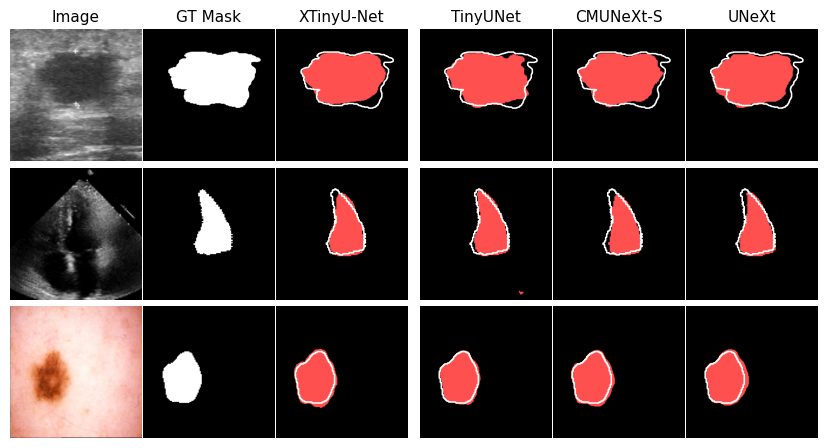

Saved figure: results/MICCAI2026/qualitative_results/qualitative_results_seed493669_part2.svg


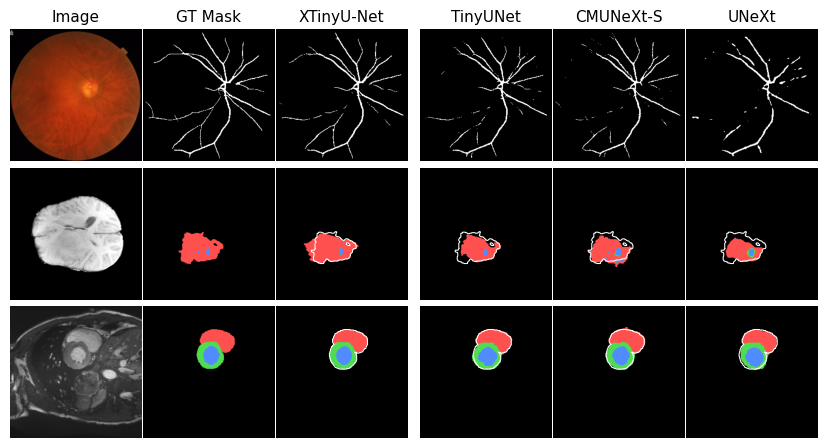

In [29]:
# Ensure deterministic qualitative output seed even if setup cell wasn't re-run
RNG_SEED = 493669
print(f'Using qualitative RNG seed in render cell: {RNG_SEED}')


PALETTE = {
    1: np.array([255, 80, 80], dtype=np.float32),
    2: np.array([80, 220, 80], dtype=np.float32),
    3: np.array([80, 140, 255], dtype=np.float32),
    4: np.array([255, 215, 0], dtype=np.float32),
    5: np.array([220, 80, 255], dtype=np.float32),
    6: np.array([80, 240, 240], dtype=np.float32),
}

# Build qualitative rows once.
rows_data = []
issue_flags = []

TABLE1_LABELS = set()
if 'TABLES' in globals() and isinstance(TABLES, dict):
    for _tname, _specs in TABLES.items():
        if str(_tname).lower().startswith('table 1'):
            TABLE1_LABELS = set([_lbl for _lbl, _ids in _specs])
            break

for ds_label, ds_ids in DATASET_ORDER:
    ds_name = _resolve_dataset_name_local(ds_ids)
    if ds_name is None:
        rows_data.append({'ds_label': ds_label, 'error': 'dataset not found'})
        continue

    picked = _pick_case_meta(ds_name)
    if picked is None:
        rows_data.append({'ds_label': ds_label, 'error': 'no image/label pairs'})
        continue

    gt = _load_array(picked['gt_path']).astype(np.int32)
    gt = np.squeeze(gt)

    z = d_ax = None
    gt2d = gt
    _xtiny_aligned_for_slice = None
    if gt.ndim == 3:
        _xt_mdir = _get_model_dir_local('XTinyU-Net', ds_name)
        _xt_pfile = _find_pred_file(_xt_mdir, ds_name, picked['case_id'])
        if _xt_pfile is not None:
            _xt_pred = _load_pred_label_map(_xt_pfile)
            _xtiny_aligned_for_slice = _align_like(_xt_pred, gt)

        z, d_ax = _choose_slice(gt, pred=_xtiny_aligned_for_slice)
        gt2d = _slice_at(gt, z, d_ax)

    base_rgb = _load_case_input_display(picked, z_idx=z, d_axis=d_ax)
    if base_rgb is None:
        rows_data.append({'ds_label': ds_label, 'error': 'input load failed'})
        continue

    image_canvas = _resize_to_canvas(base_rgb, size=256)
    gt_mask_rgb = _labels_to_mask_rgb(gt2d, single_class_color=np.array([255, 255, 255], dtype=np.float32))
    gt_mask_canvas = _resize_to_canvas_mask(gt_mask_rgb, size=256)

    pred_single_color = np.array([255, 80, 80], dtype=np.float32) if ds_label in TABLE1_LABELS else np.array([255, 255, 255], dtype=np.float32)

    _xtiny_pred2d_for_display = None
    if gt.ndim == 3 and z is not None and d_ax is not None and _xtiny_aligned_for_slice is not None:
        if _xtiny_aligned_for_slice.ndim == 3:
            _xtiny_pred2d_for_display = _slice_at(_xtiny_aligned_for_slice, z, d_ax)
        elif _xtiny_aligned_for_slice.ndim == 2:
            _xtiny_pred2d_for_display = _xtiny_aligned_for_slice

    model_overlays = {}
    model_flags = {}
    for m in MODELS_FOR_QUAL:
        pred_overlay = None
        flag = None

        mdir = _get_model_dir_local(m, ds_name)
        pfile = _find_pred_file(mdir, ds_name, picked['case_id'])
        if pfile is not None:
            pred = _load_pred_label_map(pfile)

            pred2d = None
            aligned = _align_like(pred, gt)
            if aligned is not None:
                if aligned.ndim == 3:
                    pred2d = _slice_at(aligned, z, d_ax)
                else:
                    pred2d = aligned
            elif gt.ndim == 3 and z is not None and d_ax is not None:
                pred2d = _align_slice_only(pred, gt, z, d_ax)

            if pred2d is not None:
                pred_rgb = _labels_to_mask_rgb(pred2d, single_class_color=pred_single_color)
                pred_overlay = _resize_to_canvas_mask(pred_rgb, size=256)
            elif m == 'XTinyU-Net' and _xtiny_pred2d_for_display is not None:
                pred_rgb = _labels_to_mask_rgb(_xtiny_pred2d_for_display, single_class_color=pred_single_color)
                pred_overlay = _resize_to_canvas_mask(pred_rgb, size=256)
            else:
                flag = 'align_failed'
                issue_flags.append((ds_label, picked['case_id'], m, flag))
        else:
            flag = 'pred_missing'
            issue_flags.append((ds_label, picked['case_id'], m, flag))

        model_overlays[m] = pred_overlay
        model_flags[m] = flag

    rows_data.append({
        'ds_label': ds_label,
        'ds_name': ds_name,
        'case_id': picked['case_id'],
        'image_canvas': image_canvas,
        'gt_mask_canvas': gt_mask_canvas,
        'gt_mask_bin_canvas': (gt_mask_canvas[..., 0] > 0),
        'model_overlays': model_overlays,
        'model_flags': model_flags,
        'slice_info': f'z={z}, axis={d_ax}' if z is not None else '2d',
    })

row_by_label = {r.get('ds_label'): r for r in rows_data}

QUAL_BASE = Path('results/MICCAI2026') / 'qualitative_results'
QUAL_BASE.mkdir(parents=True, exist_ok=True)

# Split figures by TABLE groups (Table 1 and Table 2).
if 'TABLES' in globals() and isinstance(TABLES, dict):
    DATASET_GROUPS = [(title, [label for label, _ids in specs]) for title, specs in TABLES.items()]
else:
    DATASET_GROUPS = [('Qualitative results', [label for label, _ids in DATASET_ORDER])]

for group_title, group_labels in DATASET_GROUPS:
    group_rows = [row_by_label.get(lbl, {'ds_label': lbl, 'error': 'dataset not found'}) for lbl in group_labels]

    n_rows = len(group_rows)
    n_cols = 2 + len(MODELS_FOR_QUAL)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.5 * n_rows), squeeze=False)

    axes[0, 0].set_title('Image', fontsize=11)
    axes[0, 1].set_title('GT Mask', fontsize=11)
    for j, m in enumerate(MODELS_FOR_QUAL, start=2):
        axes[0, j].set_title(m, fontsize=11)

    for i, row in enumerate(group_rows):
        for j in range(n_cols):
            axes[i, j].axis('off')

        if 'error' in row:
            axes[i, 0].text(0.02, 0.5, f"{row['ds_label']}\n{row['error']}", va='center', ha='left', fontsize=10)
            continue

        ylab = f"{row['ds_label']}\n{row['case_id']}\n{row['slice_info']}"
        axes[i, 0].imshow(row['image_canvas'])
        axes[i, 0].set_ylabel(ylab, rotation=0, ha='right', va='center', labelpad=42, fontsize=9)
        axes[i, 1].imshow(row['gt_mask_canvas'])

        for j, m in enumerate(MODELS_FOR_QUAL, start=2):
            ov = row['model_overlays'].get(m)
            if ov is not None:
                axes[i, j].imshow(ov)
                if row.get('ds_name') != 'Dataset309_FIVES':
                    _lw = 1.1 if row.get('ds_label') in ('BUS-BRA', 'EchoNet Dynamic', 'ISIC2018') else .75
                    axes[i, j].contour(row['gt_mask_bin_canvas'].astype(float), levels=[0.5], colors='white', linewidths=_lw)

    fig.subplots_adjust(left=0.11, right=0.995, top=0.95, bottom=0.03, wspace=0.01, hspace=0.01)

    # Add a small extra gap between XTinyU-Net and the remaining baselines.
    if 'XTinyU-Net' in MODELS_FOR_QUAL:
        _xt_col = 2 + MODELS_FOR_QUAL.index('XTinyU-Net')
        _extra_gap = 0.012
        for _i in range(n_rows):
            for _j in range(_xt_col + 1, n_cols):
                _pos = axes[_i, _j].get_position()
                axes[_i, _j].set_position([_pos.x0 + _extra_gap, _pos.y0, _pos.width, _pos.height])

    _idx = DATASET_GROUPS.index((group_title, group_labels)) + 1
    _suffix = '' if len(DATASET_GROUPS) == 1 else f'_part{_idx}'
    _fpath = QUAL_BASE / f'qualitative_results_seed{RNG_SEED}{_suffix}.svg'
    fig.savefig(_fpath, format='svg', dpi=300, bbox_inches='tight', pad_inches=0)
    print(f'Saved figure: {_fpath}')
    plt.show()

